# **YULU**

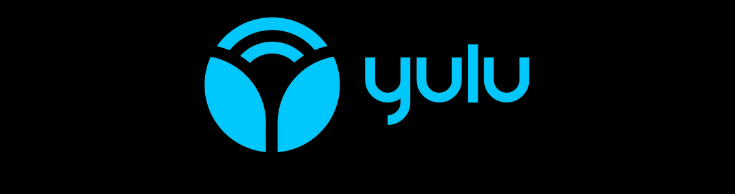

***Yulu is India’s leading micro-mobility service provider, which offers unique vehicles for the daily commute. Starting off as a mission to eliminate traffic congestion in India, Yulu provides the safest commute solution through a user-friendly mobile app to enable shared, solo and sustainable commuting.***

***Yulu zones are located at all the appropriate locations (including metro stations, bus stands, office spaces, residential areas, corporate offices, etc) to make those first and last miles smooth, affordable, and convenient!***

***Yulu has recently suffered considerable dips in its revenues. They have contracted a consulting company to understand the factors on which the demand for these shared electric cycles depends. Specifically, they want to understand the factors affecting the demand for these shared electric cycles in the Indian market.***

#**1. Define the Problem Statement, Import the required Libraries and perform Exploratory Data Analysis.**
**a. Examine dataset structure, characteristics, and statistical summary.**

**i. Hint: You can use .shape, .info(), .describe()**

**b. Identify missing values and perform Imputation using an appropriate method if needed.**
**i. Hint: You can use .isnull() or .isna()**

**c. Identify and remove duplicate records.**

**i. Hint: You can use .duplicated()**

**d. Analyze the distribution of Numerical & Categorical variables, separately**

**Hint:**

**i. For Numerical features use Histogram, Distplot, etc.**

**ii. Hint: For Categorical features use Countplot, Pie Chart, etc.**

**e. Check for Outliers and deal with them accordingly.**

**Hint:**

**i. You can use Boxplot, Interquartile Range (IQR)**

**ii. Remove/Clip existing outliers as necessary.**

# **Problem Statement:**

**The company wants to know:**

* **Which variables are significant in predicting the demand for shared electric cycles in the Indian market?**

* **How well those variables describe the electric cycle demands.**

# **Features Of The Dataset**

**datetime**: datetime

**season**: season (1: spring, 2: summer, 3: fall, 4: winter)

**holiday**: whether day is a holiday or not (extracted from http://dchr.dc.gov/page/holiday-schedule)

**workingday**: if day is neither weekend nor holiday is 1, otherwise is 0.

**weather**:
1: Clear, Few clouds, partly cloudy, partly cloudy

2: Mist + Cloudy, Mist + Broken clouds, Mist + Few clouds, Mist

3: Light Snow, Light Rain + Thunderstorm + Scattered clouds, Light Rain + Scattered clouds

4: Heavy Rain + Ice Pallets + Thunderstorm + Mist, Snow + Fog

**temp**: temperature in Celsius

**atemp**: feeling temperature in Celsius

**humidity**: humidity

**windspeed**: wind speed

**casual**: count of casual users

**registered**: count of registered users

**count**: count of total rental bikes including both casual and registered

In [1]:
#Importing libraries -
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm, chi2_contingency, f_oneway, kruskal, kstest, mannwhitneyu, ttest_ind, shapiro, levene, zscore
from statsmodels.graphics.gofplots import qqplot
import gdown
!gdown 1CSNpLvlueB5EOirtqmsgrg9-qLfM-OzB

Downloading...
From: https://drive.google.com/uc?id=1CSNpLvlueB5EOirtqmsgrg9-qLfM-OzB
To: /content/yulu_bike_sharing.csv
100% 648k/648k [00:00<00:00, 11.6MB/s]


In [2]:
data= pd.read_csv('yulu_bike_sharing.csv')
pd.options.display.max_columns=999
pd.options.display.max_rows=999
data2= data.copy()
data.head(5)

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


**Getting Basic Info About The Dataset**

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB


*>**Insight:** The dataset consists of 1 columns containing object datatype, while 8 column contains integer datatype and 3 column contains float64 datatype*

**Converting Columns To Category**

In [4]:
data['datetime']= pd.to_datetime(data['datetime'], errors='coerce')
data['season']= data['season'].replace({1: 'spring', 2: 'summer', 3: 'fall', 4: 'winter'})
data['season']= data['season'].astype('category')
data['holiday']= data['holiday'].replace({1: 'yes', 0: 'no'})
data['holiday']= data['holiday'].astype('category')
data['workingday']= data['workingday'].replace({1: 'yes', 0: 'no'})
data['workingday']= data['workingday'].astype('category')
data['weather']= data['weather'].replace({1: 'Clear', 2: 'Mist', 3: 'Light_Snow', 4: 'Heavy_Rain'})
data['weather']= data['weather'].astype('category')
data.rename({'count':'total_rides'}, axis= 1, inplace= True)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   datetime     10886 non-null  datetime64[ns]
 1   season       10886 non-null  category      
 2   holiday      10886 non-null  category      
 3   workingday   10886 non-null  category      
 4   weather      10886 non-null  category      
 5   temp         10886 non-null  float64       
 6   atemp        10886 non-null  float64       
 7   humidity     10886 non-null  int64         
 8   windspeed    10886 non-null  float64       
 9   casual       10886 non-null  int64         
 10  registered   10886 non-null  int64         
 11  total_rides  10886 non-null  int64         
dtypes: category(4), datetime64[ns](1), float64(3), int64(4)
memory usage: 723.7 KB


*>**Insight:** The dataset consists of 1 columns containing datetime64[ns] datatype, 4 column contains integer datatype, 3 column contains float64 datatype and 4 column contains category datatype*

**Shape Of Dataset**

In [6]:
data.shape

(10886, 12)

**Duplicate Values**

In [7]:
data.duplicated().any()

False

In [8]:
data.duplicated().sum()

0

*>**Insight:** There are no duplicate rows in dataset.*

**Statistical Summary**

In [9]:
data.describe()

,datetime,temp,atemp,humidity,windspeed,casual,registered,total_rides
count,10886,10886.00000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000
mean,2011-12-27 05:56:22.399411968,20.23086,23.655084,61.886460,12.799395,36.021955,155.552177,191.574132
min,2011-01-01 00:00:00,0.82000,0.760000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2011-07-02 07:15:00,13.94000,16.665000,47.000000,7.001500,4.000000,36.000000,42.000000
50%,2012-01-01 20:30:00,20.50000,24.240000,62.000000,12.998000,17.000000,118.000000,145.000000
75%,2012-07-01 12:45:00,26.24000,31.060000,77.000000,16.997900,49.000000,222.000000,284.000000
max,2012-12-19 23:00:00,41.00000,45.455000,100.000000,56.996900,367.000000,886.000000,977.000000
std,NaN,7.79159,8.474601,19.245033,8.164537,49.960477,151.039033,181.144454


*>**Insight:** This function calculates summary statistics, including count, mean, standard deviation, minimum, 25th percentile, median (50th percentile), 75th percentile, and maximum, for numerical columns within the DataFrame. These statistics aid in comprehending the central tendency, spread, and distribution of the data.*

In [10]:
data.describe(include= 'category').T

,count,unique,top,freq
season,10886,4,winter,2734
holiday,10886,2,no,10575
workingday,10886,2,yes,7412
weather,10886,4,Clear,7192


*>**Insight:** This command retrieves information about categorical data within the DataFrame, including the count of observations, the number of unique categories, the most frequent category, and its frequency for each categorical column.*

**Missing Values**

In [11]:
data.isna().any().any()

False

In [12]:
data.isna().sum().sum()

0

*>**Insight:** There are no missing values in dataset.*

**Graphical Analysis And Non-Graphical Analysis​**


**Unique Values**

In [13]:
data.nunique()

,0
datetime,10886
season,4
holiday,2
workingday,2
weather,4
temp,49
atemp,60
humidity,89
windspeed,28
casual,309


**Univariate Analysis**

**Categorical Distribution**

In [14]:
cat= np.array(data.select_dtypes('category').columns)
for i in cat:
    print(i.upper())
    print()
    print(data[i].value_counts())
    print(data[i].value_counts(normalize= True)*100)
    print('-'*50)

SEASON

season
winter    2734
fall      2733
summer    2733
spring    2686
Name: count, dtype: int64
season
winter    25.114826
fall      25.105640
summer    25.105640
spring    24.673893
Name: proportion, dtype: float64
--------------------------------------------------
HOLIDAY

holiday
no     10575
yes      311
Name: count, dtype: int64
holiday
no     97.14312
yes     2.85688
Name: proportion, dtype: float64
--------------------------------------------------
WORKINGDAY

workingday
yes    7412
no     3474
Name: count, dtype: int64
workingday
yes    68.087452
no     31.912548
Name: proportion, dtype: float64
--------------------------------------------------
WEATHER

weather
Clear         7192
Mist          2834
Light_Snow     859
Heavy_Rain       1
Name: count, dtype: int64
weather
Clear         66.066507
Mist          26.033437
Light_Snow     7.890869
Heavy_Rain     0.009186
Name: proportion, dtype: float64
--------------------------------------------------


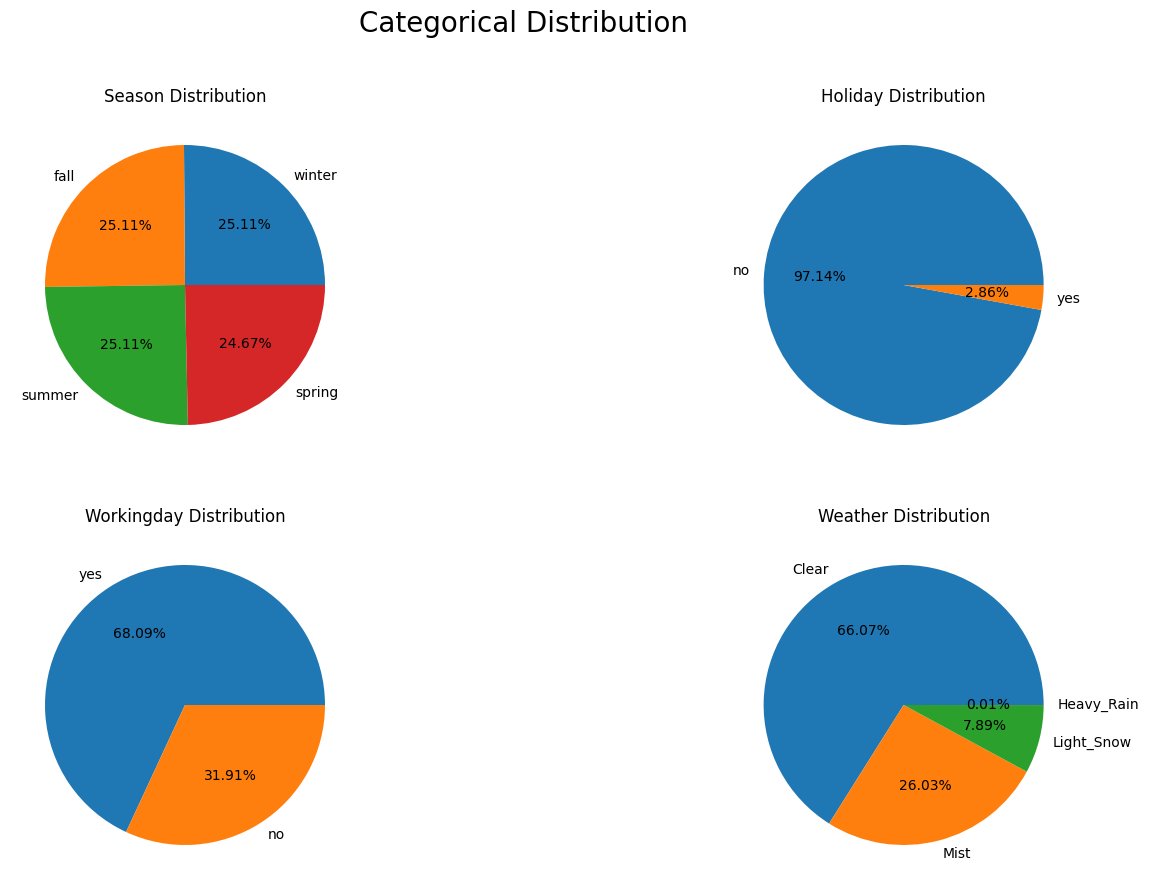

In [15]:
plt.figure(figsize=(17,10))
for j,i in enumerate(cat):
    plt.subplot(2,2,j+1)
    plt.title(f'{i.title()} Distribution')
    value= data[i].value_counts()
    type_data= data[i].value_counts().index
    plt.pie(value, labels= type_data, autopct= '%2.2f%%')
plt.suptitle('Categorical Distribution', fontsize=20)
plt.show()

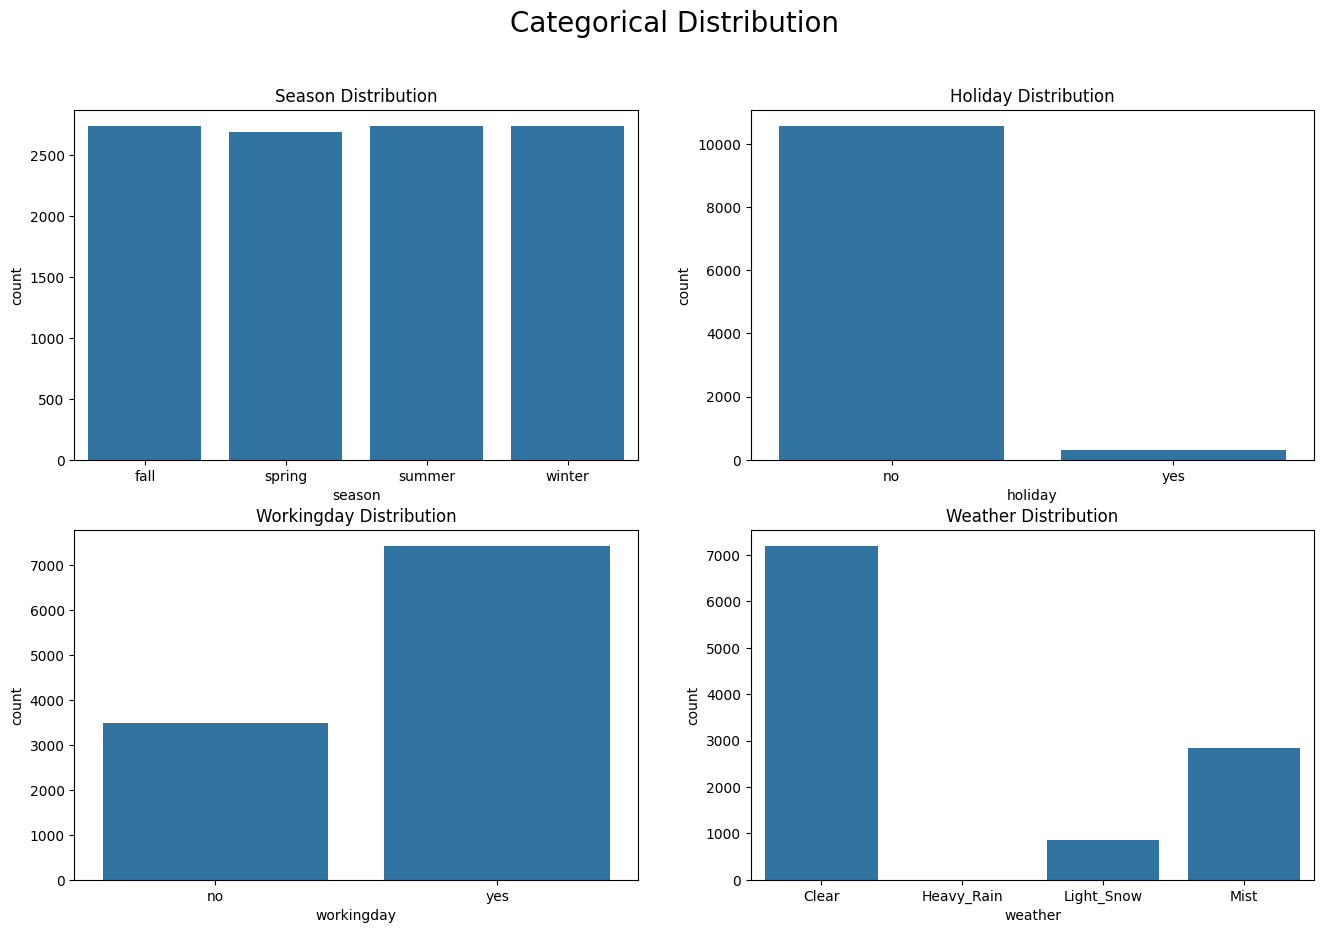

In [92]:
plt.figure(figsize=(16,10))
for j,i in enumerate(cat):
    plt.subplot(2,2,j+1)
    plt.title(f'{i.title()} Distribution')
    sns.countplot(data, x= i)
plt.suptitle('Categorical Distribution', fontsize=20)
plt.show()

**Continuous Distribution**

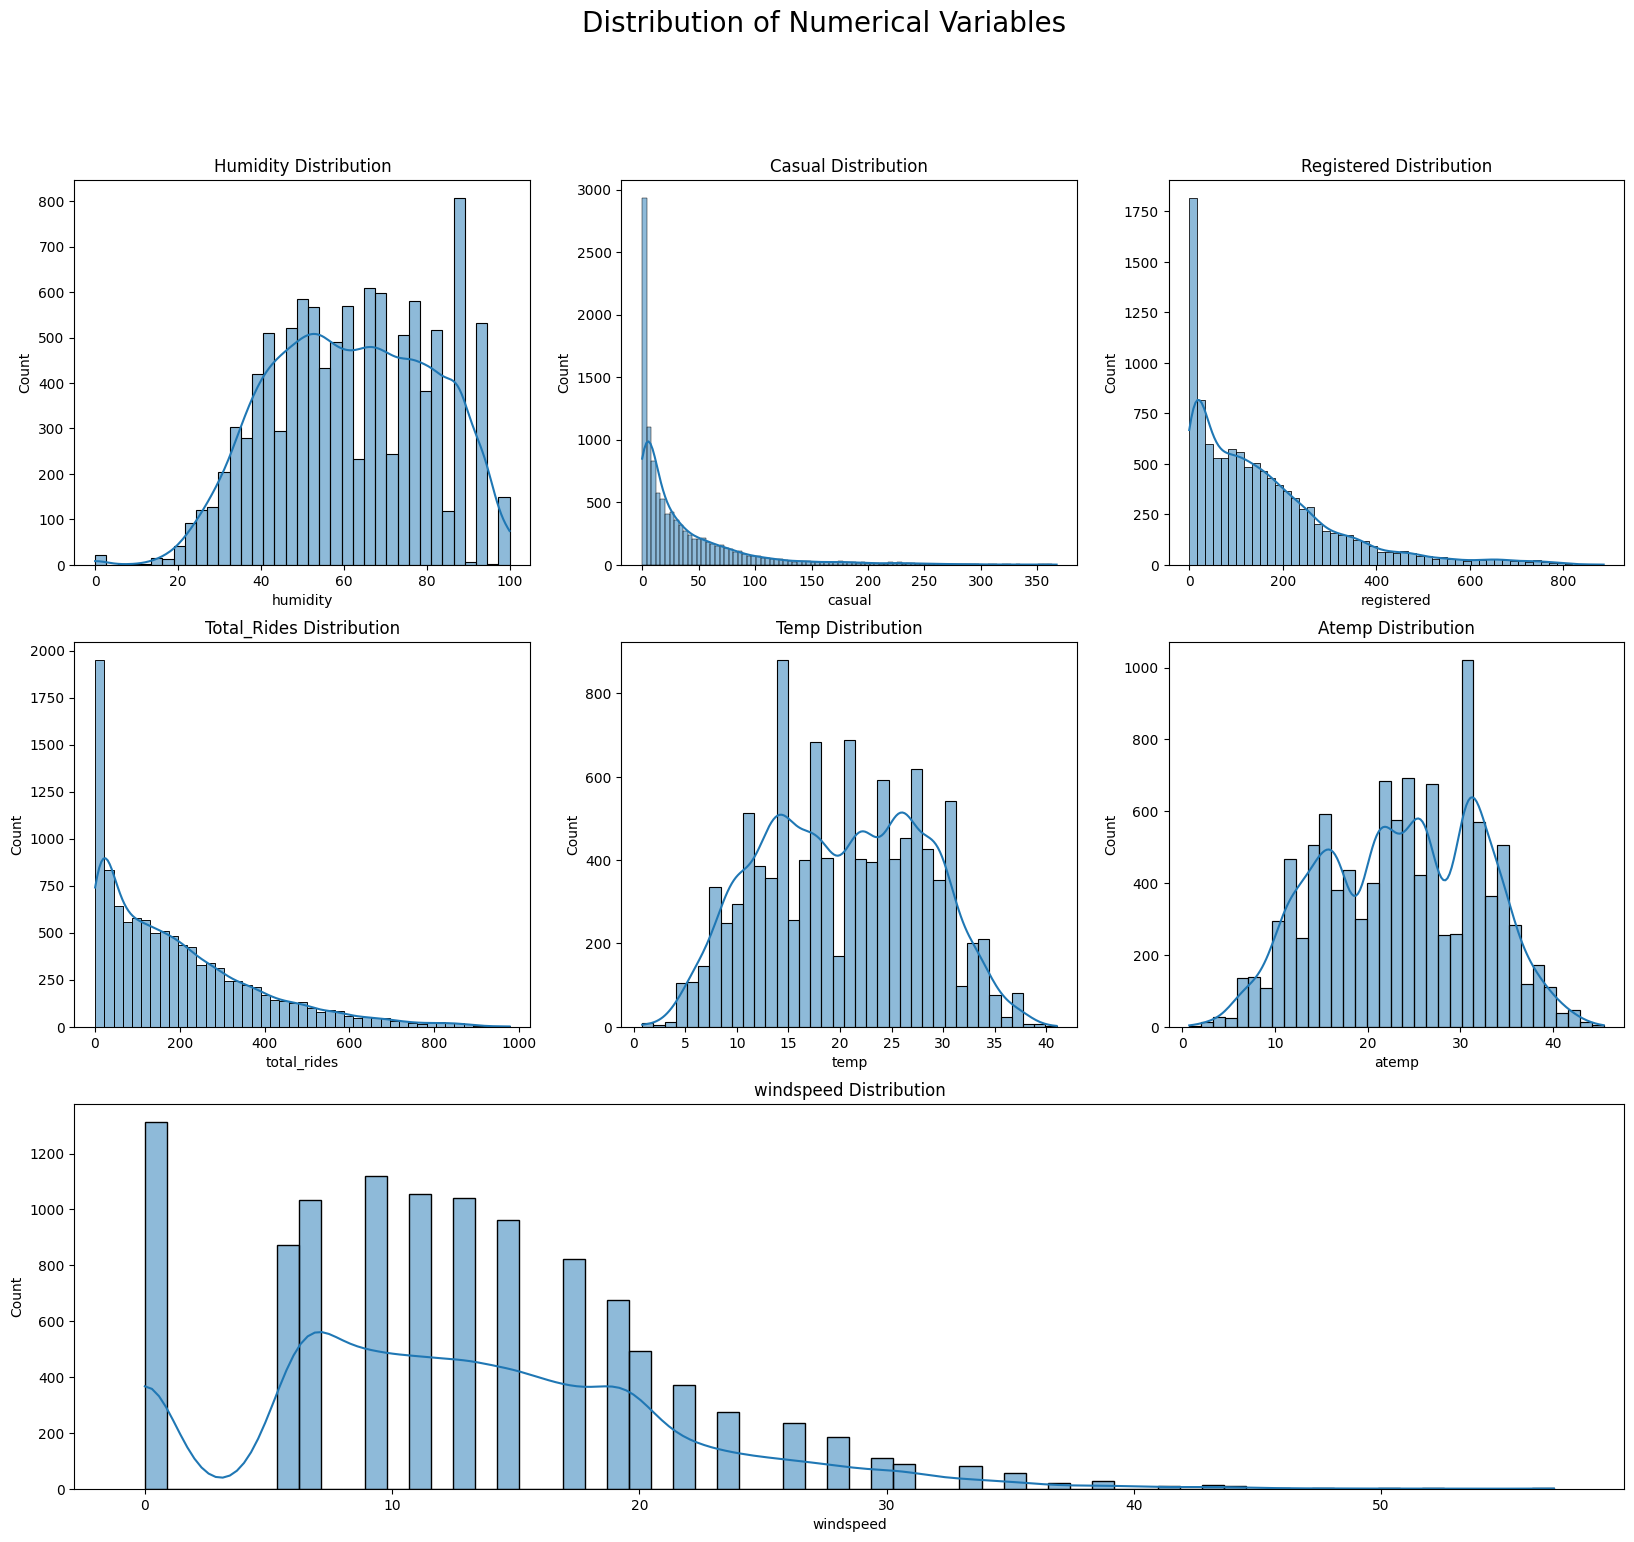

In [17]:
num= ['humidity', 'casual', 'registered', 'total_rides', 'temp', 'atemp']
plt.figure(figsize=(20,17)).suptitle("Distribution of Numerical Variables", fontsize=20)
for j,i in enumerate(num):
    plt.subplot(3,3,j+1)
    plt.title(f'{i.title()} Distribution')
    sns.histplot(data, x= i, kde=True)
plt.subplot(3,1,3)
plt.title('windspeed Distribution')
sns.histplot(data, x= 'windspeed', kde=True)
plt.show()

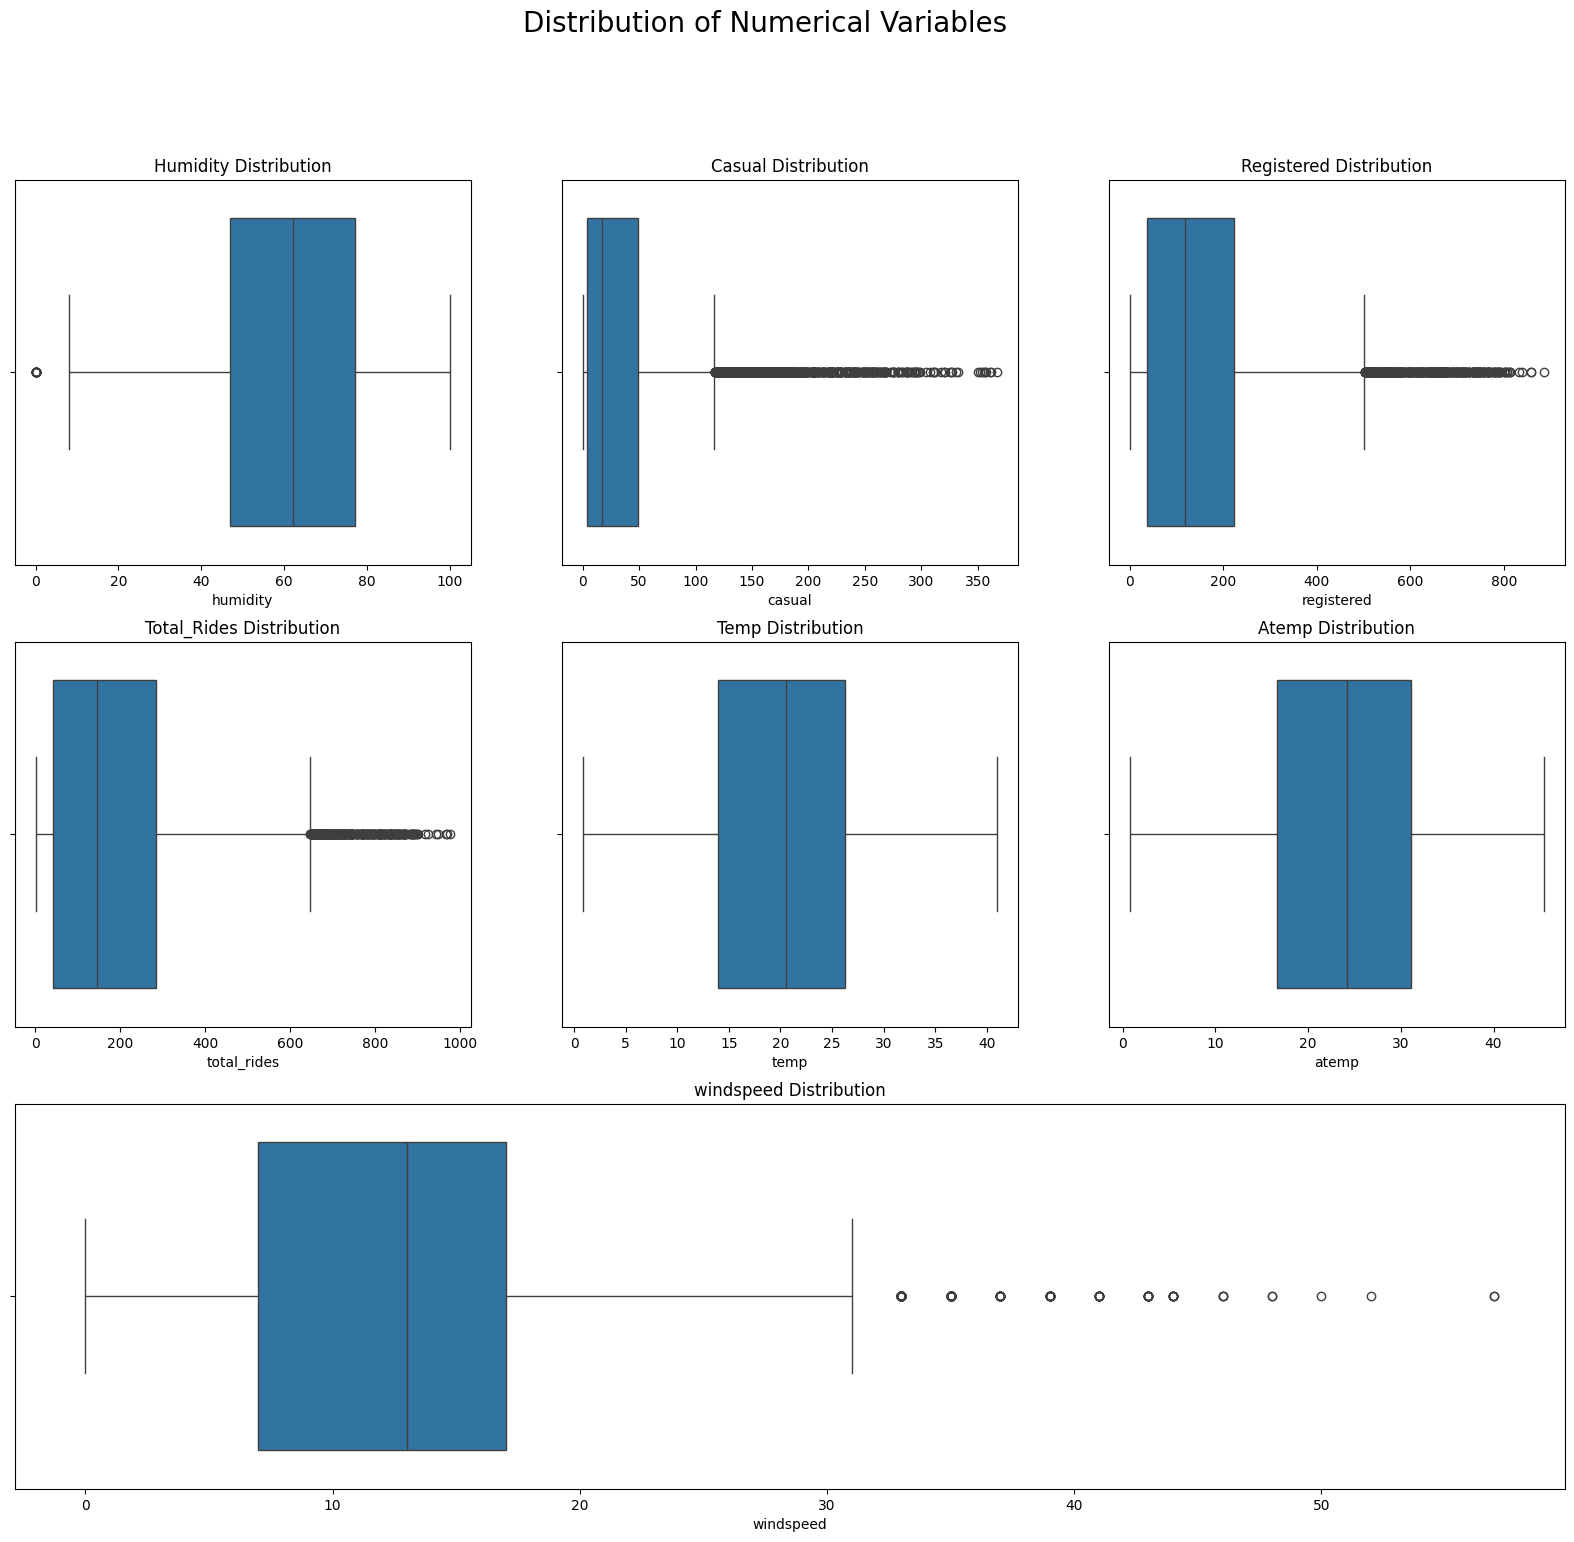

In [18]:
plt.figure(figsize=(20,17)).suptitle("Distribution of Numerical Variables", fontsize=20)
for j,i in enumerate(num):
    plt.subplot(3,3,j+1)
    plt.title(f'{i.title()} Distribution')
    sns.boxplot(data, x= i)
plt.subplot(3,1,3)
plt.title('windspeed Distribution')
sns.boxplot(data, x= 'windspeed')
plt.show()

**Outliers**

In [19]:
for i in data.select_dtypes('number').columns:
    print(i.upper())
    q1=data[i].quantile(0.25)
    q3=data[i].quantile(0.75)
    IQR=q3-q1
    print(f'Q1: {q1}, Q2: {q3}, IQR: {IQR}')
    outliers = data[((data[i]<(q1-1.5*IQR)) | (data[i]>(q3+1.5*IQR)))]
    print("No Of Outliers: ", len(outliers))
    print("Percent Of Outliers : ", len(outliers)/len(data)*100)
    print('-'*50)
    print()

TEMP
Q1: 13.94, Q2: 26.24, IQR: 12.299999999999999
No Of Outliers:  0
Percent Of Outliers :  0.0
--------------------------------------------------

ATEMP
Q1: 16.665, Q2: 31.06, IQR: 14.395
No Of Outliers:  0
Percent Of Outliers :  0.0
--------------------------------------------------

HUMIDITY
Q1: 47.0, Q2: 77.0, IQR: 30.0
No Of Outliers:  22
Percent Of Outliers :  0.20209443321697593
--------------------------------------------------

WINDSPEED
Q1: 7.0015, Q2: 16.9979, IQR: 9.996400000000001
No Of Outliers:  227
Percent Of Outliers :  2.085247106375161
--------------------------------------------------

CASUAL
Q1: 4.0, Q2: 49.0, IQR: 45.0
No Of Outliers:  749
Percent Of Outliers :  6.880396839977953
--------------------------------------------------

REGISTERED
Q1: 36.0, Q2: 222.0, IQR: 186.0
No Of Outliers:  423
Percent Of Outliers :  3.885724784126401
--------------------------------------------------

TOTAL_RIDES
Q1: 42.0, Q2: 284.0, IQR: 242.0
No Of Outliers:  300
Percent Of Out

***As we can see that except 'CASUAL' column other numarical columns have very less outliers and we will NOT treat them as they are important in hypothesis testing. For 'CASUAL', I prefer to analyze the reasons behind those outliers, particularly within the 'CASUAL'. I want to understand how casual users contributed to these 6.88% outliers and identify the factors that helped Yulu handle such bookings. By examining their behavior, we can gain valuable insights into Yulu’s success.***

**Bivariate Analysis**

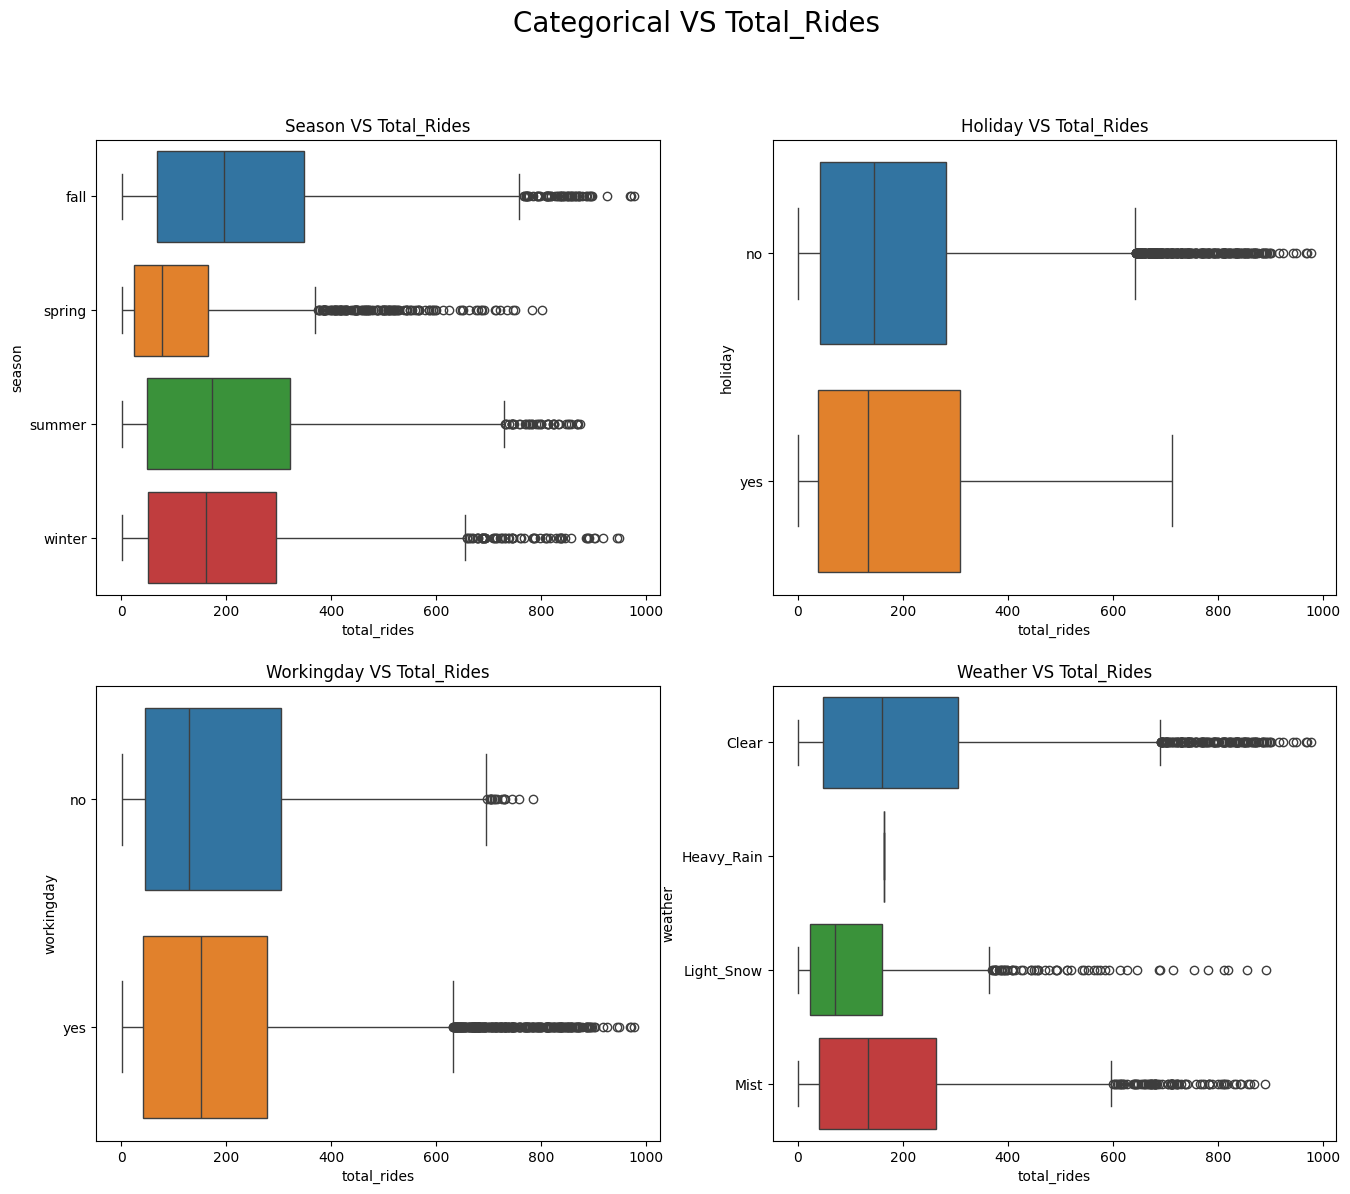

In [20]:
plt.figure(figsize=(16,13))
for j,i in enumerate(cat):
    plt.subplot(2,2,j+1)
    plt.title(f'{i.title()} VS Total_Rides')
    sns.boxplot(data, x= 'total_rides', y= i, hue= i)
plt.suptitle('Categorical VS Total_Rides', fontsize=20)
plt.show()

# **2. Try Establishing A Relationship Between The Dependent And Independent Variables.**
**Hint:**

**i. Plot a Correlation Heatmap and draw insights.**

**ii. Remove the highly correlated variables, if any.**

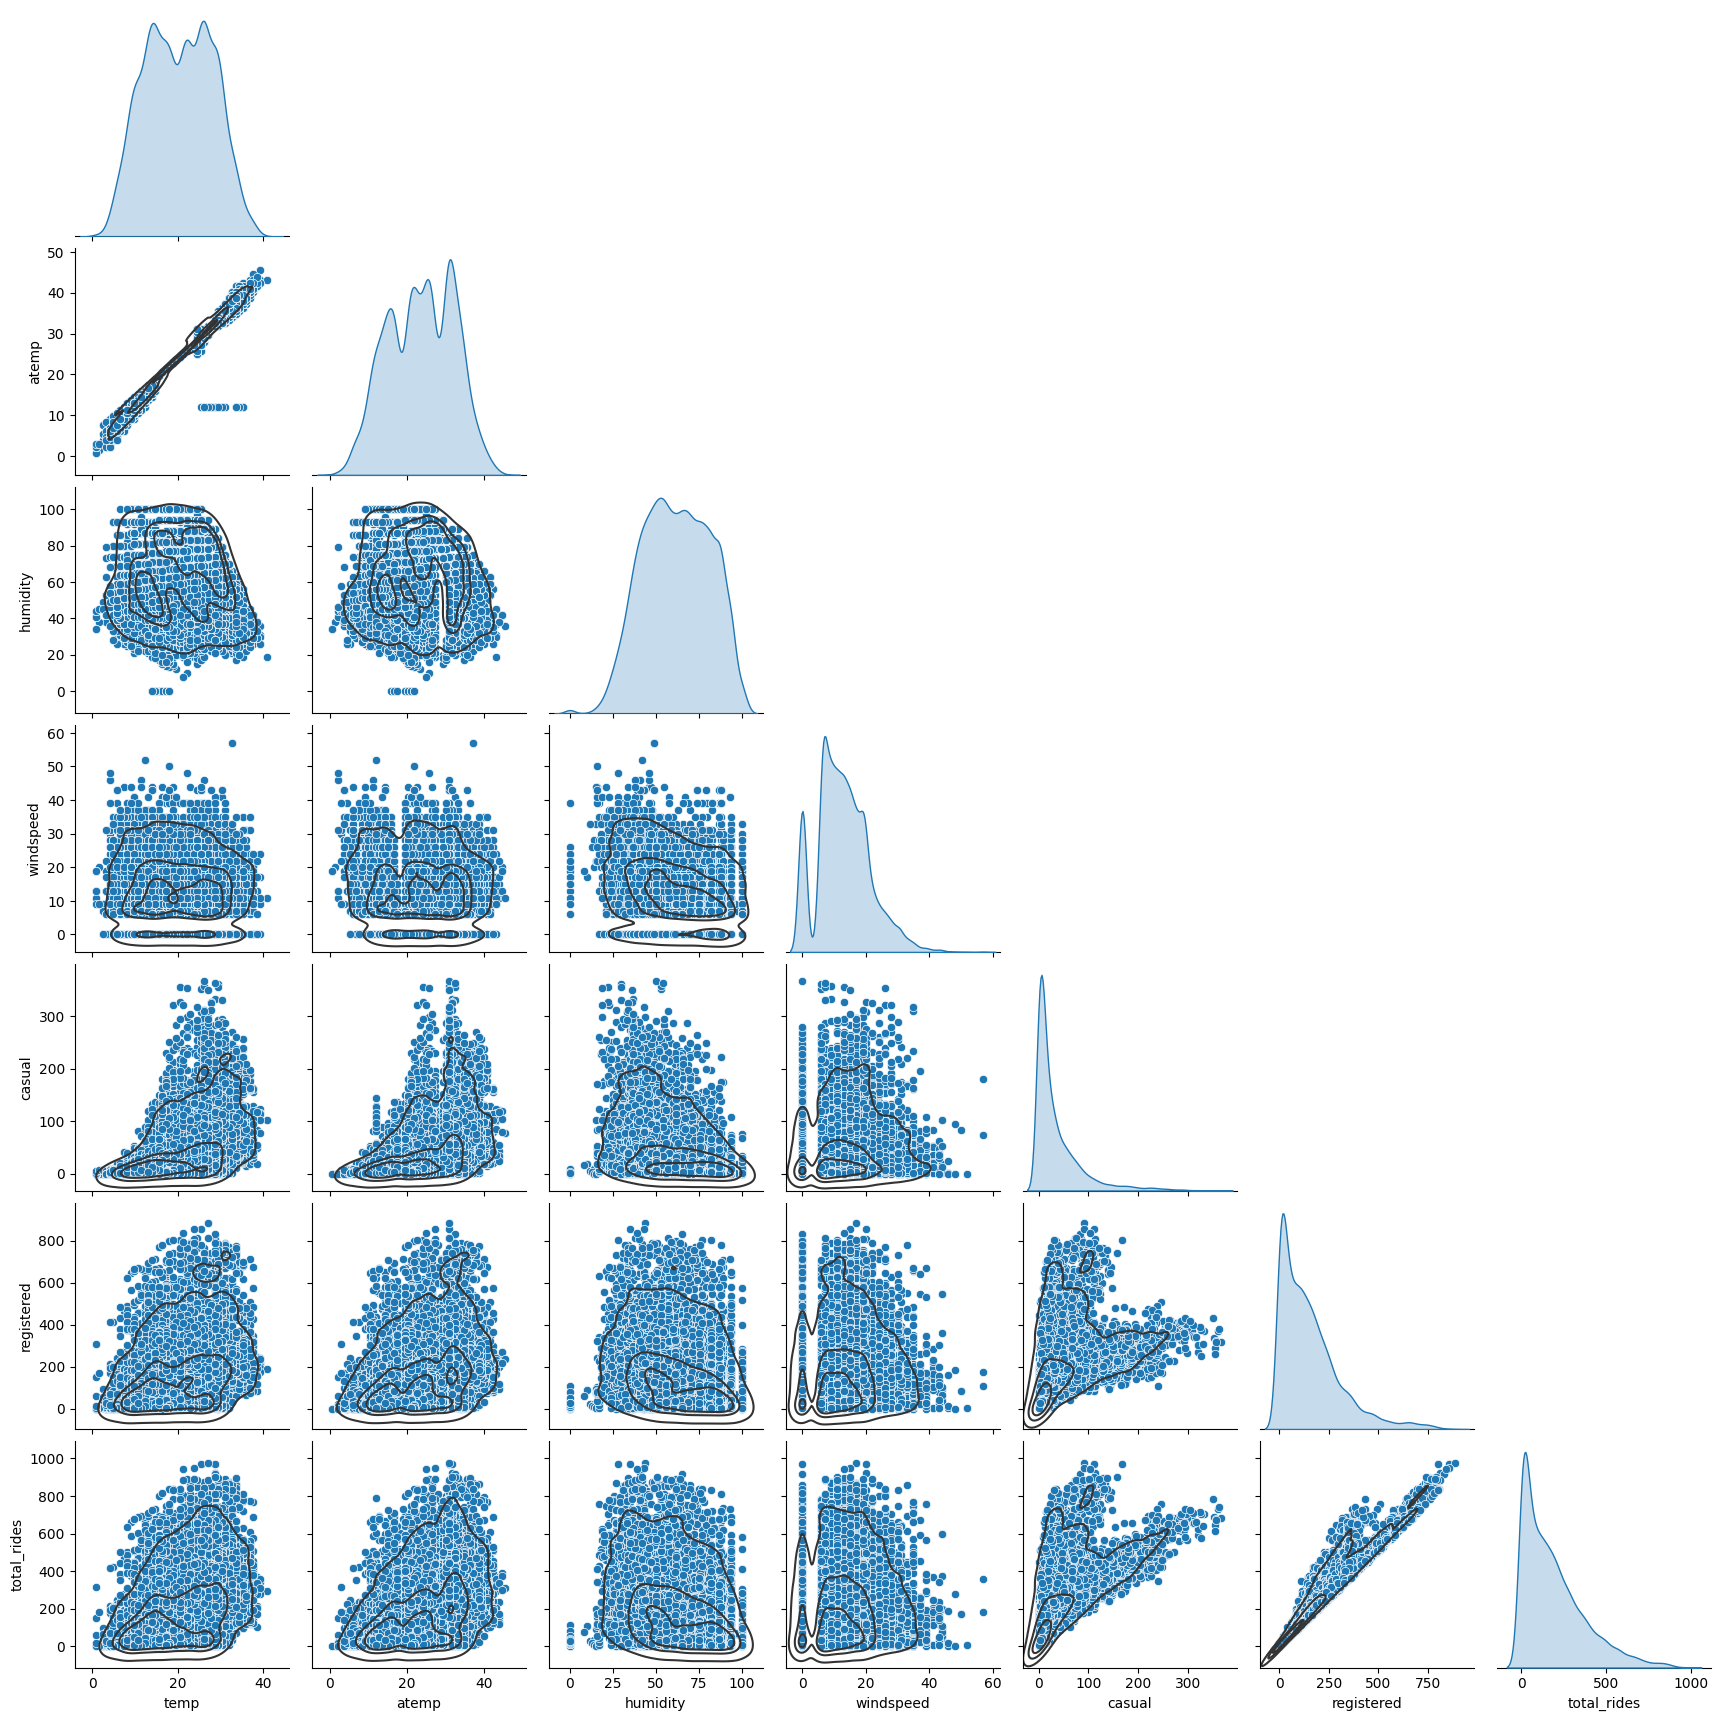

In [21]:
g= sns.pairplot(data= data, corner=True, diag_kind="kde") #, kind= 'kde')
g.map_lower(sns.kdeplot, levels=4, color=".2")
plt.show()

In [22]:
data2.corr(numeric_only=True)

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
season,1.000000,0.029368,-0.008126,0.008879,0.258689,0.264744,0.190610,-0.147121,0.096758,0.164011,0.163439
holiday,0.029368,1.000000,-0.250491,-0.007074,0.000295,-0.005215,0.001929,0.008409,0.043799,-0.020956,-0.005393
workingday,-0.008126,-0.250491,1.000000,0.033772,0.029966,0.024660,-0.010880,0.013373,-0.319111,0.119460,0.011594
weather,0.008879,-0.007074,0.033772,1.000000,-0.055035,-0.055376,0.406244,0.007261,-0.135918,-0.109340,-0.128655
temp,0.258689,0.000295,0.029966,-0.055035,1.000000,0.984948,-0.064949,-0.017852,0.467097,0.318571,0.394454
atemp,0.264744,-0.005215,0.024660,-0.055376,0.984948,1.000000,-0.043536,-0.057473,0.462067,0.314635,0.389784
humidity,0.190610,0.001929,-0.010880,0.406244,-0.064949,-0.043536,1.000000,-0.318607,-0.348187,-0.265458,-0.317371
windspeed,-0.147121,0.008409,0.013373,0.007261,-0.017852,-0.057473,-0.318607,1.000000,0.092276,0.091052,0.101369
casual,0.096758,0.043799,-0.319111,-0.135918,0.467097,0.462067,-0.348187,0.092276,1.000000,0.497250,0.690414
registered,0.164011,-0.020956,0.119460,-0.109340,0.318571,0.314635,-0.265458,0.091052,0.497250,1.000000,0.970948


<Axes: >

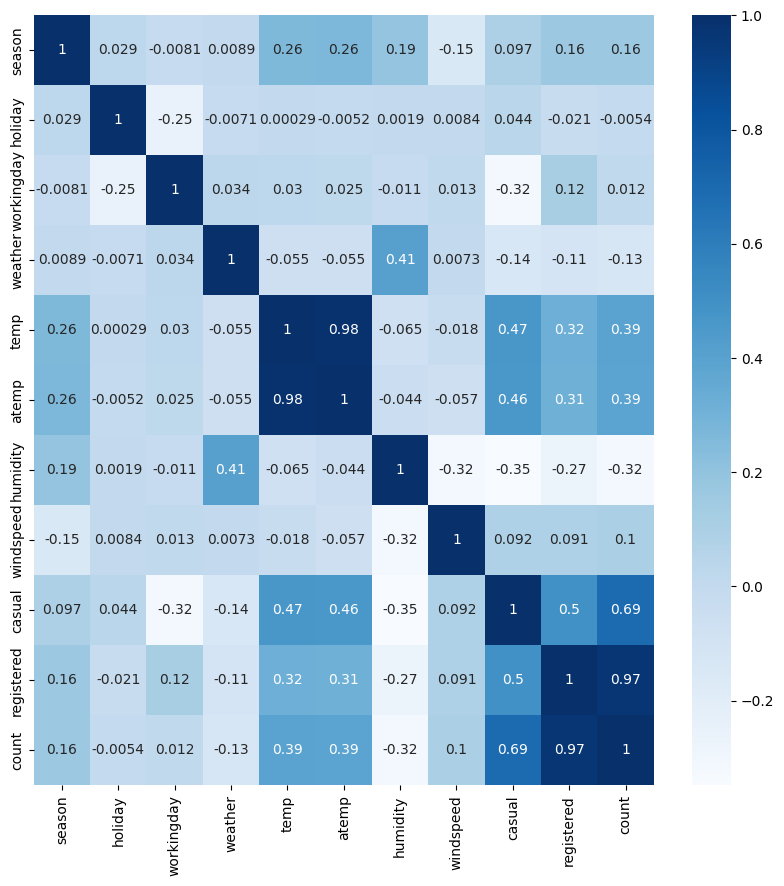

In [23]:
plt.figure(figsize = (10,10))
sns.heatmap(data2.corr(numeric_only=True), annot = True, cmap= "Blues")

**Removing highly correlated variables is important for several reasons:**

1. **Multicollinearity**:

When two or more independent variables in a dataset are highly correlated, it can lead to multicollinearity. This means that the variables provide redundant information about the dependent variable. Multicollinearity can make it difficult to determine the individual effect of each variable on the dependent variable.

2. **Model Stability**:

High multicollinearity can cause the coefficients of the regression model to become unstable. Small changes in the data can lead to large changes in the model coefficients, making the model unreliable.

3. **Interpretability**:

Removing highly correlated variables simplifies the model, making it easier to interpret. When variables are highly correlated, it can be challenging to understand their individual contributions to the model.

4. **Overfitting**:

Highly correlated variables can lead to overfitting, where the model performs well on the training data but poorly on new, unseen data. By removing redundant variables, we reduce the risk of overfitting and improve the model's generalizability.

**Highly Correlated Variables:**

**temp and atemp:** The correlation between temp and atemp is extremely high (0.984948). This indicates that these two variables are almost identical in terms of the information they provide. we can remove one of them, typically atemp since temp is more straightforward to interpret.

**registered and count:** The correlation between registered and count is very high (0.970948). Since count is the sum of casual and registered, including both registered and count can lead to redundancy. we can consider using count as the dependent variable and removing registered from the independent variables.

**Steps to Remove Highly Correlated Variables**

**Remove atemp:** Since temp and atemp are highly correlated, we can remove atemp.

**Remove registered:** Since registered is highly correlated with count, we can remove registered if you are using count as the dependent variable.

In [24]:
data.drop(['atemp', 'registered'], axis = 1, inplace= True)

In [25]:
data.columns

Index(['datetime', 'season', 'holiday', 'workingday', 'weather', 'temp',
       'humidity', 'windspeed', 'casual', 'total_rides'],
      dtype='object')

# **3. Check if there any significant difference between the no. of bike rides on Weekdays and Weekends?**

**a. Formulate Null Hypothesis (H0) and Alternate Hypothesis (H1)**

**b. Select an appropriate test -**

**i. Hint: 2- Sample Independent T-test**

**c. Set a significance level**

**i. Hint: alpha=5% is recommended**

**d. Calculate test Statistics / p-value**

**e. Decide whether to accept or reject the Null Hypothesis.**

**Hint:**

**i. If the p-value is less than or equal to the predetermined level of significance (alpha), we have evidence to reject the null hypothesis.**

**ii. If the p-value is greater than the predetermined level of significance
(alpha), we do not have sufficient evidence to reject the null hypothesis.**

**f. Draw inferences & conclusions from the analysis and provide recommendations.**

# **Step 1: Define The Null And Alternate Hypothesis**


$H_0:$ The demand of bikes on weekdays is SIMILAR to the demand of bikes on weekend.

$H_a:$ The demand of bikes on weekdays is NOT SIMILAR to the demand of bikes on weekend.

Let $\mu_1$ and $\mu_2$ be the average no. of bikes rented on weekdays and weekends respectively.

Mathematically, the above formulated hypothesis can be written as:

$H_0: \mu_1  =  \mu_2$

$H_a: \mu_1  !=  \mu_2$

# **Step 2: Select An Appropriate Test**

We Can use Z-test or T-test as sample size if high. Population mean and std is not known. We will use 2 Sample T-test here.

**Assumptions of T-Test**
1. The sample size should be less than 30.
2. The population variance is unknown.
3. The population mean and standard deviation are finite.
4. The means of the two populations being compared should follow normal distributions.
5. If using Student's original definition of the t-test, the two populations being compared should have the same variance. If the sample sizes in the two groups being compared are equal, Student's original t-test is highly robust to the presence of unequal variances.


# **Step 3: Checking For Basic Assumpitons For The Hypothesis.**

**Normality checks:**

Distribution check using QQ Plot

Distribution check using Hist/Kde Plot

Confirmation by Shapiro-wilks Test

**Variances checks:**

Homogeneity of Variances using Levene's test

# **Step 4: Decide a test statistic and a corresponding distribution.**

**Test Statistic**: T-Stats

**Distribution**: T-Distribution

If data follows normal distribution we go with ttest_ind

Else we will go with Mannwhitney_u test (Non - Parametric test)

# **Step 5: Determine whether the test should be left-tailed, right-tailed, or two-tailed.**

We will perform two-tailed and later go with left or right tailed test after the results of two-tailed test, if needed.

# **Step 6: Determine the p-value and Choose a significance level.**

we will be computing the t-stat value using the ttest function using scip.stats.

We set our alpha to be 0.05 (i.e) confidence level = 95%

# **Step 7: Compare p-value and alpha.**
Based on p-value, we will accept or reject Ho.

p-val > alpha : Failed To Reject Ho

p-val < alpha : Reject Ho


In [26]:
data['workingday'].value_counts()

,count
workingday,
yes,7412
no,3474


In [27]:
weekdays_rides= data.loc[data['workingday']=='yes', 'total_rides'].sample(3400)
weekends_rides= data.loc[data['workingday']=='no', 'total_rides'].sample(3400)

**Why do we take same no. of samples from two different populations for conducting the tests?**

**Ans.**
* Unequal sample sizes can lead to unequal variances between samples, which affects the assumption of equal variances in tests like t-test, ANOVA, etc.

* Having both unequal sample sizes and variances dramatically affects the statistical power of a test.

# **Normality Checks**

# **Weekdays_rides- QQTEST for normality**

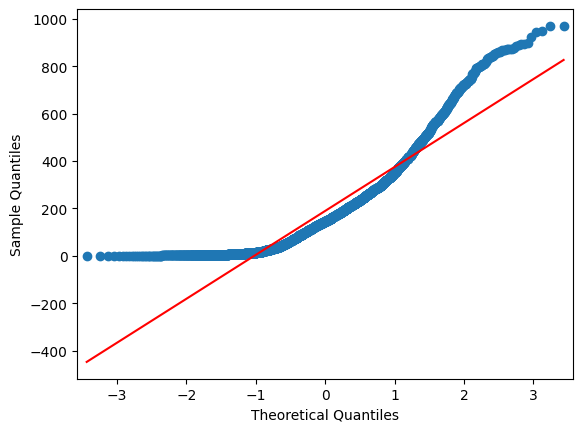

In [28]:
qqplot(weekdays_rides, line= 's')
plt.show()

# **Weekends_rides- QQTEST for normality**

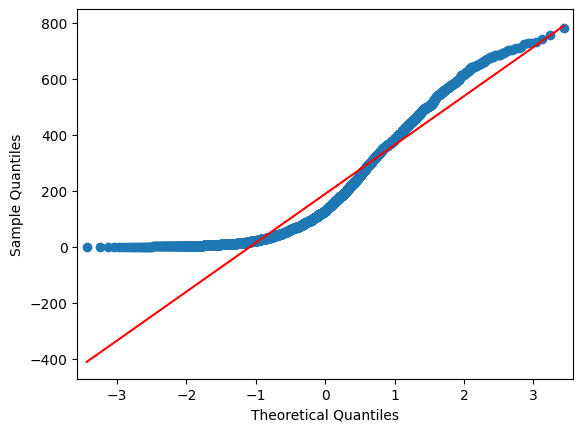

In [29]:
qqplot(weekends_rides, line= 's')
plt.show()

**From QQTEST we can see that the rides demands on weekdays or weekends do NOT follow normal distribution.**

# **Histplot/Kdeplot Test for Normality**

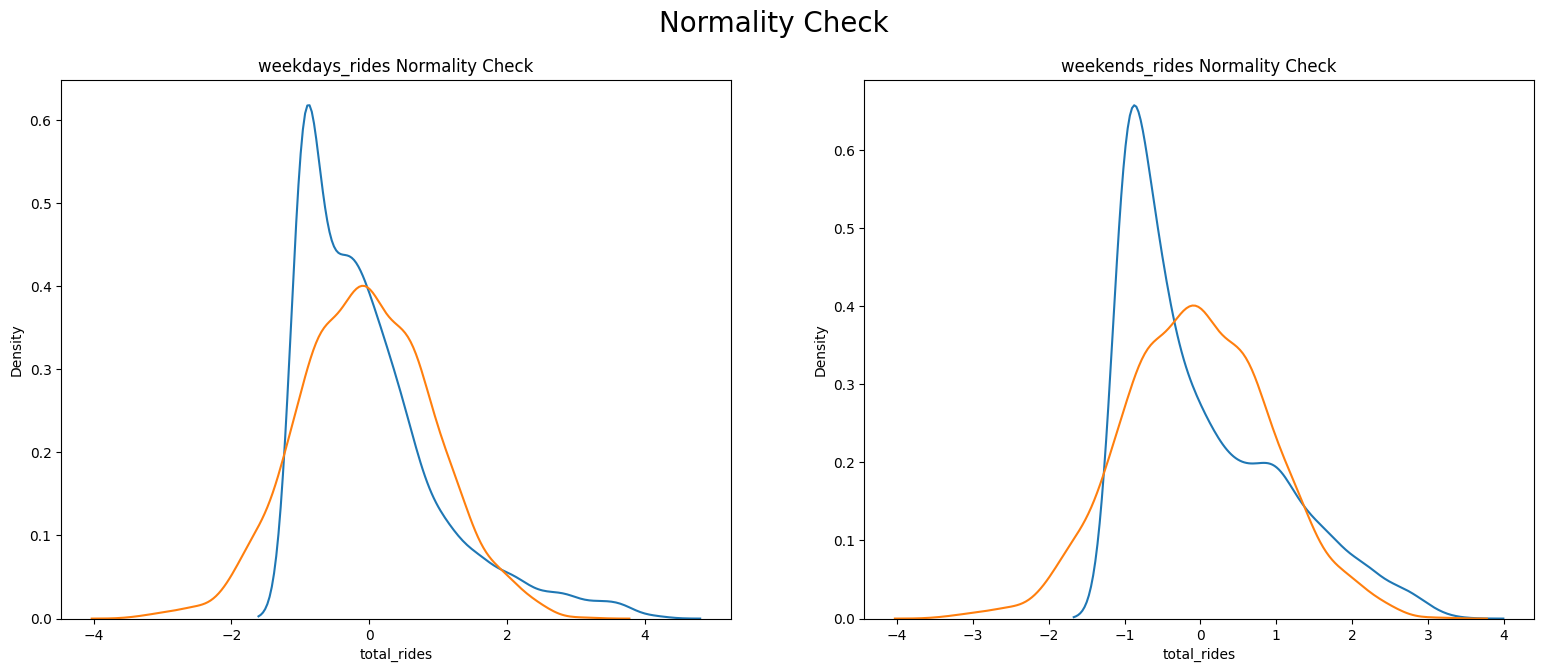

In [30]:
std_norm= np.random.normal(0, 1, 3000)

weekdays_rides_z= zscore(weekdays_rides)
weekends_rides_z= zscore(weekends_rides)

plt.figure(figsize = (19,7))
plt.suptitle('Normality Check', fontsize=20)

plt.subplot(1,2,1)
plt.title('weekdays_rides Normality Check')
sns.kdeplot(weekdays_rides_z)
sns.kdeplot(std_norm)

plt.subplot(1,2,2)
plt.title('weekends_rides Normality Check')
sns.kdeplot(weekends_rides_z)
sns.kdeplot(std_norm)
plt.show()

**From KDE PLOT we can see that the rides demands on weekdays or weekends do NOT follow normal distribution.**

# **Shapiro Test For Normality**

>$H_o:$ Data follows Gaussian distribution

>$H_a:$ Data do NOT follow Gaussian distribution

In [31]:
#weekdays_rides
shapiro_stat , p_val = shapiro(weekdays_rides)
print(f"Shapiro_stat : {shapiro_stat} , P_Value : {p_val}")
print()
if p_val > 0.05:
	print('Data Follows Gaussian distribution')
else:
	print('Data Do NOT Follow Gaussian distribution')

Shapiro_stat : 0.8604220242894228 , P_Value : 7.449009774320694e-48

Data Do NOT Follow Gaussian distribution


In [32]:
#weekends_rides
shapiro_stat , p_val = shapiro(weekends_rides)
print(f"Shapiro_stat : {shapiro_stat} , P_Value : {p_val}")
print()
if p_val > 0.05:
	print('Data Follows Gaussian distribution')
else:
	print('Data Do NOT Follow Gaussian distribution')

Shapiro_stat : 0.885489384617844 , P_Value : 1.1422463684780477e-44

Data Do NOT Follow Gaussian distribution


**We conclude that the samples do not follow normal distribution**

# **Variances Checks**

In [33]:
data.groupby('workingday', observed=True)['total_rides'].describe()

,count,mean,std,min,25%,50%,75%,max
workingday,,,,,,,,
no,3474.0,188.506621,173.724015,1.0,44.0,128.0,304.0,783.0
yes,7412.0,193.011873,184.513659,1.0,41.0,151.0,277.0,977.0


#**Levene’s test**

>$H_0$: All the count variances are equal

>$H_a$: At least one variance is different from the rest

In [34]:
levene_stat, p_val = levene(weekends_rides, weekdays_rides)
print(f"Levene_stat : {levene_stat} , P_Value : {p_val}")
print()
if p_val > 0.05:
	print('Data Has Similar Variance')
else:
	print('Data Do NOT Have Similar Variance')

Levene_stat : 0.39146225588129535 , P_Value : 0.5315527816833543

Data Has Similar Variance


**Here we can see that both groups have same variance.**

**We conclude that the 2 sample have same variance but are not normally distributed. T-Test cannot be applied here, we can perform its non parametric
equivalent test i.e., Mann-Whitney U rank test for two independent samples. But we will try to compare both tests.**

# **2-Sample Independent T-Test**

In [35]:
def test_result(p_value, alpha):
    if p_value < alpha:
        print(f'As the p-value {p_value} is less than the level of significance, we reject the null hypothesis.')
    else:
        print(f'As the p-value {p_value} is greater than the level of significance, we fail to reject the null hypothesis.')

**Two-Tailed Test**

In [36]:
test_stat, p_value = ttest_ind(weekdays_rides, weekends_rides)
print(f"Test_stat : {test_stat} , P_Value : {p_value}")
print()
alpha = 0.05
test_result(p_value, alpha)

Test_stat : 0.002761791108712882 , P_Value : 0.9977964933525125

As the p-value 0.9977964933525125 is greater than the level of significance, we fail to reject the null hypothesis.


**Test Result: We Fail to reject Null Hypothesis that means there is no significant difference between weekdays and weekends ride counts**

# **MannWhitney u Rank test(Non-Parametric Test)**

In [37]:
test_stat, p_value = mannwhitneyu(weekdays_rides, weekends_rides)
print(f"Test_stat : {test_stat} , P_Value : {p_value}")
print()
alpha = 0.05
test_result(p_value, alpha)

Test_stat : 5675654.0 , P_Value : 0.19734567933339886

As the p-value 0.19734567933339886 is greater than the level of significance, we fail to reject the null hypothesis.


**Test Result: We Fail to reject Null Hypothesis that means there is no significant difference between weekdays and weekends ride counts**

**From both 2-Sample T-Test and MannWhitney U Rank Test we conclude that there is no significant difference between weekdays and weekends ride counts.**

# **4. Check if the demand of bicycles on rent is the same for different Weather conditions?**

**a. Formulate Null Hypothesis (H0) and Alternate Hypothesis (H1)**

**b. Select an appropriate test -**

**i. Hint: One-way ANOVA test**

**c. Check assumptions of the test**

**i. Normality**

**Hint:**

**1. Use Histogram, Q-Q Plot, Skewness & Kurtosis**

**2. Shapiro-Wilk’s test**

**ii. Equality Variance**

**Hint:**

**1. Levene’s test**

**iii. Please continue doing the analysis even if some assumptions fail
(Levene’s test or Shapiro-wilk test) but double check using visual
analysis and report wherever necessary**

**d. Set a significance level and Calculate the test Statistics / p-value.**

**i. Hint: alpha=5% is recommended**

**e. Decide whether to accept or reject the Null Hypothesis.**

**Hint:**

**i. If the p-value is less than or equal to the predetermined level of
significance (alpha), we have evidence to reject the null hypothesis.**

**ii. If the p-value is greater than the predetermined level of significance
(alpha), we do not have sufficient evidence to reject the null hypothesis.
f. Draw inferences & conclusions from the analysis and provide recommendations.**

# **Step 1: Define the null and alternate hypothesis**

$H_0:$ The average no. of bike rides in different weather conditions  are equal.

$H_a:$ The average no. of bike rides in different weather conditions are not equal.

Let $\mu_1$, $\mu_2$ and $\mu_3$ be the average no. of bikes rented on different weather conditions respectively.

Mathematically, the above formulated hypothesis can be written as:

$H_0: \mu_1  =  \mu_2 = \mu_3$

$H_a: \mu_1  !=  \mu_2 != \mu_3$

# **Step 2: Select An Appropriate Test**

**One-way ANOVA** could be the appropriate test here provided normality and equality of variance assumptions are verified.

The ANOVA test has important assumptions that must be satisfied in order for the associated p-value to be valid.

**Assumptions of T-Test**

* The samples are independent.
* Each sample is from a normally distributed population.
* The population variance of the groups are all equal.

# **Step 3: Checking For Basic Assumpitons For The Hypothesis.**

**Normality checks:**

Distribution check using QQ Plot

Distribution check using Hist/kds Plot

Confirmation by Shapiro-wilks Test

Confirmation by KS Test

Check Skewness & Kurtosis

**Variances checks:**

Homogeneity of Variances using Levene's test

# **Step 4: Decide a test statistic and a corresponding distribution.**

**Test Statistic**: F-Stats

**Distribution**: F-Distribution

If data follows normal distribution and similar variance we go with ANOVA test

Else we will go with kruskal-Wallis test(Non - Parametric test)

# **Step 5: Determine whether the test should be left-tailed, right-tailed, or two-tailed.**

We will perform two-tailed and later go with left or right tailed test after the results of two-tailed test, if needed.

# **Step 6: Determine the p-value and Choose a significance level.**

we will be computing the F-stat value using the ANOVA function using scip.stats.

We set our alpha to be 0.05 (i.e) confidence level = 95%

# **Step 7: Compare p-value and alpha.**
Based on p-value, we will accept or reject Ho.

p-val > alpha : Failed To Reject Ho

p-val < alpha : Reject Ho

In [38]:
data['weather'].value_counts()

,count
weather,
Clear,7192
Mist,2834
Light_Snow,859
Heavy_Rain,1


We are going to ignore Heavy_Rain weather as we have only 1 data point.

In [39]:
Clear_weather= data.loc[data['weather']=='Clear', 'total_rides'].sample(800)
Mist_weather= data.loc[data['weather']=='Mist', 'total_rides'].sample(800)
Light_Snow_weather= data.loc[data['weather']=='Light_Snow', 'total_rides'].sample(800)

**Why do we take same no. of samples from two different populations for conducting the tests?**

**Ans.**
* Unequal sample sizes can lead to unequal variances between samples, which affects the assumption of equal variances in tests like t-test, ANOVA, etc.

* Having both unequal sample sizes and variances dramatically affects the statistical power of a test.

# **Normality Checks**

# **Clear_weather- QQTEST for normality**

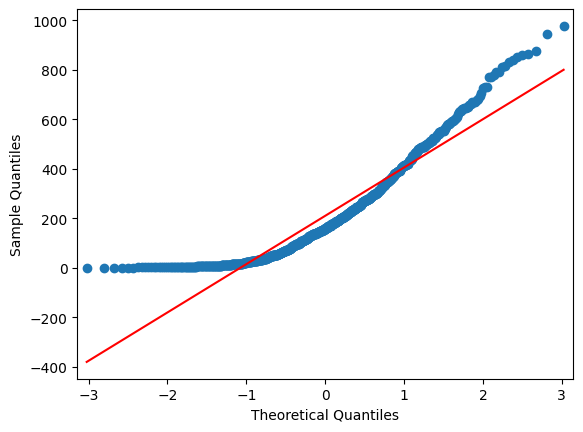

In [40]:
qqplot(Clear_weather, line= 's')
plt.show()

# **Mist_weather- QQTEST for normality**

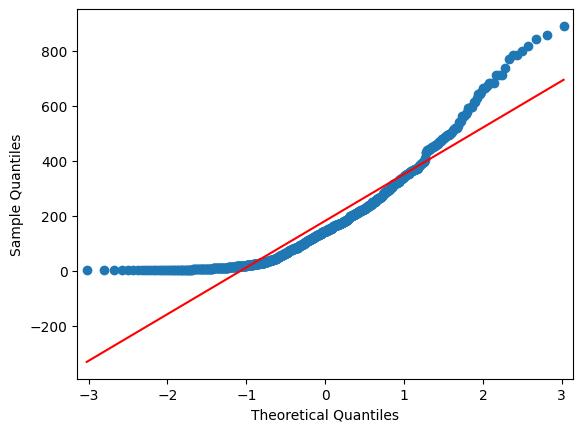

In [41]:
qqplot(Mist_weather, line= 's')
plt.show()

**Light_Snow_weather- QQTEST for normality**

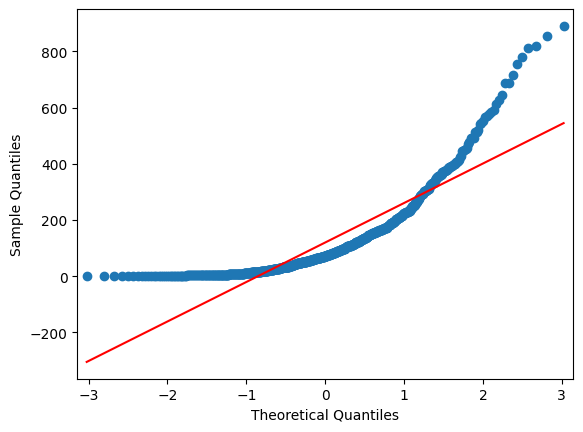

In [42]:
qqplot(Light_Snow_weather, line= 's')
plt.show()

**From QQTEST we can see that the rides demands on diffrent types of weather do NOT follow normal distribution.**

# **Histplot/Kdeplot Test for Normality**

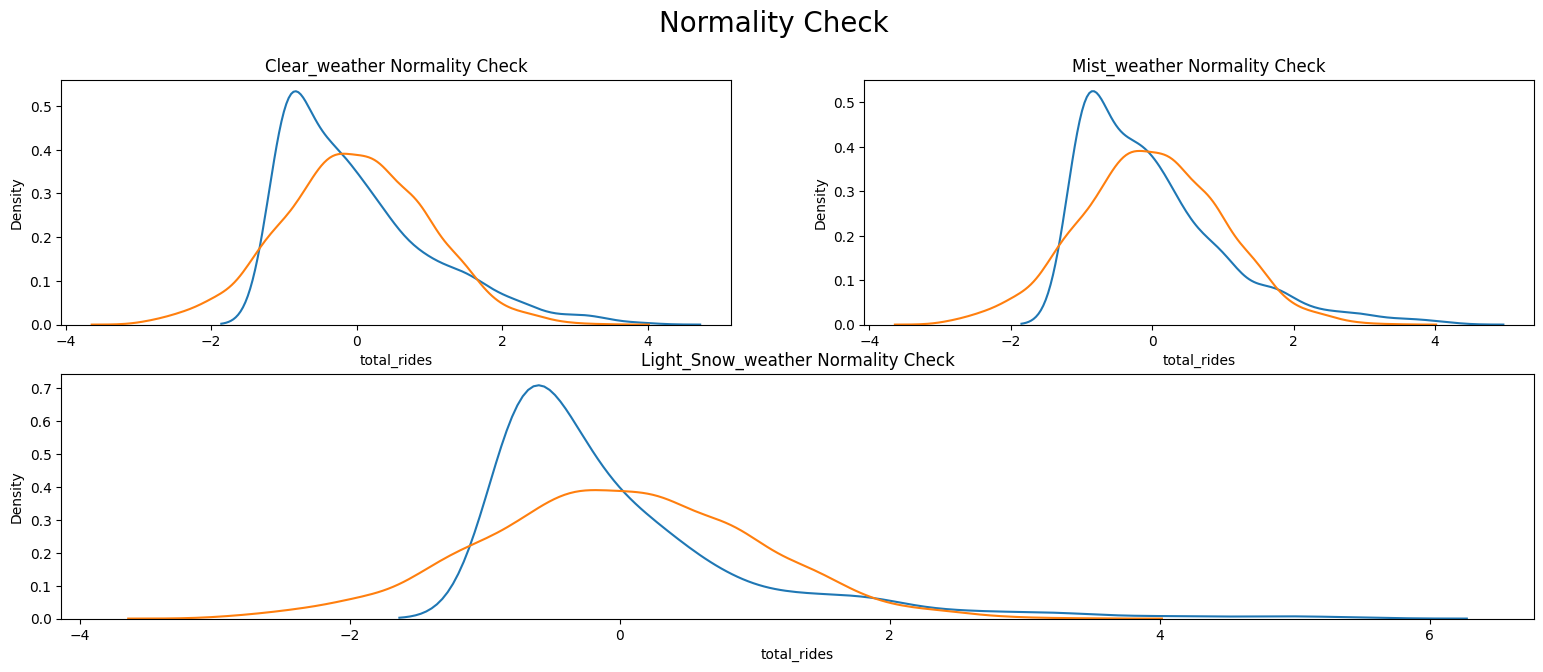

In [43]:
std_norm= np.random.normal(0, 1, 3000)

Clear_weather_z= zscore(Clear_weather)
Mist_weather_z= zscore(Mist_weather)
Light_Snow_weather_z= zscore(Light_Snow_weather)

plt.figure(figsize = (19,7))
plt.suptitle('Normality Check', fontsize=20)

plt.subplot(2,2,1)
plt.title('Clear_weather Normality Check')
sns.kdeplot(Clear_weather_z)
sns.kdeplot(std_norm)

plt.subplot(2,2,2)
plt.title('Mist_weather Normality Check')
sns.kdeplot(Mist_weather_z)
sns.kdeplot(std_norm)

plt.subplot(2,1,2)
plt.title('Light_Snow_weather Normality Check')
sns.kdeplot(Light_Snow_weather_z)
sns.kdeplot(std_norm)
plt.show()

**From KDE Plot we can see that the rides demands on diffrent types of weather do NOT follow normal distribution.**

# **Check Skewness & Kurtosis**

In [44]:
print("Skewness of Clear_weather: ", Clear_weather.skew())
print("Kurtosis of Clear_weather: ", Clear_weather.kurt())
print('-'*50)
print("Skewness of Mist_weather: ", Mist_weather.skew())
print("Kurtosis of Mist_weather: ", Mist_weather.kurt())
print('-'*50)
print("Skewness of Light_Snow_weather: ", Light_Snow_weather.skew())
print("Kurtosis of Light_Snow_weather: ", Light_Snow_weather.kurt())

Skewness of Clear_weather:  1.158820356999767
Kurtosis of Clear_weather:  0.9648004691221876
--------------------------------------------------
Skewness of Mist_weather:  1.3279841689440084
Kurtosis of Mist_weather:  1.7865374483588798
--------------------------------------------------
Skewness of Light_Snow_weather:  2.1986272652846037
Kurtosis of Light_Snow_weather:  5.969165678494036


**We can see that there is skewness and kurtosis in different weather rides**

# **Kolmogorov-Smirnov Test For Normality**

>$H_o:$ Data follows Gaussian distribution

>$H_a:$ Data do NOT follow Gaussian distribution

In [45]:
kstat, p_value= kstest(Clear_weather_z, 'norm')
print('Clear_weather:')
print(f"Test_stat : {kstat} , P_Value : {p_value}")
print()
alpha = 0.05
test_result(p_value, alpha)
print('-'*50)
print()

kstat, p_value= kstest(Mist_weather_z, 'norm')
print('Mist_weather:')
print(f"Test_stat : {kstat} , P_Value : {p_value}")
print()
alpha = 0.05
test_result(p_value, alpha)
print('-'*50)
print()

kstat, p_value= kstest(Light_Snow_weather_z, 'norm')
print('Light_Snow_weather:')
print(f"Test_stat : {kstat} , P_Value : {p_value}")
print()
alpha = 0.05
test_result(p_value, alpha)

Clear_weather:
Test_stat : 0.1420160414421845 , P_Value : 1.533022540501123e-14

As the p-value 1.533022540501123e-14 is less than the level of significance, we reject the null hypothesis.
--------------------------------------------------

Mist_weather:
Test_stat : 0.14424444035689088 , P_Value : 5.465795087402468e-15

As the p-value 5.465795087402468e-15 is less than the level of significance, we reject the null hypothesis.
--------------------------------------------------

Light_Snow_weather:
Test_stat : 0.19935054661974938 , P_Value : 2.4357468235535564e-28

As the p-value 2.4357468235535564e-28 is less than the level of significance, we reject the null hypothesis.


**We can see from KS test that all the different weather values do not follow normal distribution**

# **Shapiro-Wilk’s test**

We will test the null hypothesis

>$H_0:$ Count follows normal distribution

against the alternative hypothesis

>$H_a:$ Count doesn't follow normal distribution



In [46]:
shapiro_stat, p_value= shapiro(Clear_weather)
print('Clear_weather:')
print(f"Test_stat : {shapiro_stat} , P_Value : {p_value}")
print()
alpha = 0.05
test_result(p_value, alpha)
print('-'*50)
print()

shapiro_stat, p_value= shapiro(Mist_weather)
print('Mist_weather:')
print(f"Test_stat : {shapiro_stat} , P_Value : {p_value}")
print()
alpha = 0.05
test_result(p_value, alpha)
print('-'*50)
print()

shapiro_stat, p_value= shapiro(Light_Snow_weather)
print('Light_Snow_weather:')
print(f"Test_stat : {shapiro_stat} , P_Value : {p_value}")
print()
alpha = 0.05
test_result(p_value, alpha)
print('-'*50)
print()

Clear_weather:
Test_stat : 0.885207877758689 , P_Value : 6.988364336929137e-24

As the p-value 6.988364336929137e-24 is less than the level of significance, we reject the null hypothesis.
--------------------------------------------------

Mist_weather:
Test_stat : 0.8755209494184135 , P_Value : 9.191718194378008e-25

As the p-value 9.191718194378008e-25 is less than the level of significance, we reject the null hypothesis.
--------------------------------------------------

Light_Snow_weather:
Test_stat : 0.7633187100718593 , P_Value : 2.3608921986277252e-32

As the p-value 2.3608921986277252e-32 is less than the level of significance, we reject the null hypothesis.
--------------------------------------------------



**We can see from Shapiro-Wilk’s test that all the different weather values do not follow normal distribution**

# **Variances Checks**

In [47]:
data.groupby('weather', observed=False)['total_rides'].describe()

,count,mean,std,min,25%,50%,75%,max
weather,,,,,,,,
Clear,7192.0,205.236791,187.959566,1.0,48.0,161.0,305.0,977.0
Heavy_Rain,1.0,164.000000,NaN,164.0,164.0,164.0,164.0,164.0
Light_Snow,859.0,118.846333,138.581297,1.0,23.0,71.0,161.0,891.0
Mist,2834.0,178.955540,168.366413,1.0,41.0,134.0,264.0,890.0


In [48]:
print('Variances Check:')
print(f'Clear_weather: {Clear_weather.var()}, Mist_weather: {Mist_weather.var()}, Light_Snow_weather: {Light_Snow_weather.var()}')

Variances Check:
Clear_weather: 38110.57188829787, Mist_weather: 28824.758942428045, Light_Snow_weather: 19799.047745619504


**We can see there is difference in Variances for different weather groups**

#**Levene’s test**

>$H_0$: All the count variances are equal

>$H_a$: At least one variance is different from the rest

In [49]:
levene_stat, p_value = levene(Clear_weather, Mist_weather, Light_Snow_weather)
print(f"Levene_stat : {levene_stat} , P_Value : {p_value}")
print()
alpha = 0.05
test_result(p_value, alpha)

Levene_stat : 44.70297286507094 , P_Value : 8.690686119768413e-20

As the p-value 8.690686119768413e-20 is less than the level of significance, we reject the null hypothesis.


**We can see from levene test that there is difference in Variances for different weather groups**

**The assumptions of ANOVA Test are not satisfied so we can go with KRUSKAL_WALIS H TEST. We will perform both.**

# **One-Way ANOVA Test**

In [50]:
anova_stat, p_value = f_oneway(Clear_weather, Mist_weather, Light_Snow_weather)
print(f"Anova_stat : {anova_stat} , P_Value : {p_value}")
print()
alpha = 0.05
test_result(p_value, alpha)

Anova_stat : 58.885028492530175 , P_Value : 1.0838007815400257e-25

As the p-value 1.0838007815400257e-25 is less than the level of significance, we reject the null hypothesis.


**The mean number of bikes rented is different across at weather conditions**

# **KRUSKAL_WALIS H TEST**

In [51]:
kruskal_stat, p_value = kruskal(Clear_weather, Mist_weather, Light_Snow_weather)
print(f"kruskal_stat : {kruskal_stat} , P_Value : {p_value}")
print()
alpha = 0.05
test_result(p_value, alpha)

kruskal_stat : 116.97711074138303 , P_Value : 3.969567104848172e-26

As the p-value 3.969567104848172e-26 is less than the level of significance, we reject the null hypothesis.


**From both ANOVA and KRUSKAL_WALIS H TEST we can say that the mean number of bikes rented is different across at weather conditions.**

**Let us find out Which weather has more bookings.**

**Using 2 independent sample Ttest.**

In [52]:
#Ho: u1<=u2
#Ha: u1>u2

test_stat, p_value = ttest_ind(Clear_weather, Mist_weather, alternative= 'greater')
print(f"Test_stat : {test_stat} , P_Value : {p_value}")
print()
alpha = 0.05
test_result(p_value, alpha)

Test_stat : 3.160706397641487 , P_Value : 0.0008016938610207534

As the p-value 0.0008016938610207534 is less than the level of significance, we reject the null hypothesis.


**Average booking on Clear_weather is greater than Average Mist_weather booking**

In [53]:
#Ho: u1<=u2
#Ha: u1>u2

test_stat, p_value = ttest_ind(Clear_weather, Light_Snow_weather, alternative= 'greater')
print(f"Test_stat : {test_stat} , P_Value : {p_value}")
print()
alpha = 0.05
test_result(p_value, alpha)

Test_stat : 10.617289687673503 , P_Value : 8.557613450165018e-26

As the p-value 8.557613450165018e-26 is less than the level of significance, we reject the null hypothesis.


**Average booking on Clear_weather is greater than Average Light_Snow_weather booking**

In [54]:
#Ho: u1<=u2
#Ha: u1>u2

test_stat, p_value = ttest_ind(Mist_weather, Light_Snow_weather, alternative= 'greater')
print(f"Test_stat : {test_stat} , P_Value : {p_value}")
print()
alpha = 0.05
test_result(p_value, alpha)

Test_stat : 7.878420665060065 , P_Value : 3.040190531540829e-15

As the p-value 3.040190531540829e-15 is less than the level of significance, we reject the null hypothesis.


**Average booking on Mist_weather is greater than Average Light_Snow_weather booking**

**We can say that Average booking on Clear_weather is the highest followed by Mist_weather and then Light_Snow_weather.**

# **5. Check if the demand of bicycles on rent is the same for different Seasons?**

**a. Formulate Null Hypothesis (H0) and Alternate Hypothesis (H1)**

**b. Select an appropriate test -**

**i. Hint: One-way ANOVA test**

**c. Check assumptions of the test**

**i. Normality**

**Hint:**

**1. Use Histogram, Q-Q Plot, Skewness & Kurtosis**

**2. Shapiro-Wilk’s test**

**ii. Equality Variance**

**Hint:**

**1. Levene’s test**

**iii. Please continue doing the analysis even if some assumptions fail
(Levene’s test or Shapiro-wilk test) but double check using visual
analysis and report wherever necessary**

**d. Set a significance level and Calculate the test Statistics / p-value.**

**i. Hint: alpha=5% is recommended**

**e. Decide whether to accept or reject the Null Hypothesis.**

**Hint:**

**i. If the p-value is less than or equal to the predetermined level of
significance (alpha), we have evidence to reject the null hypothesis.**

**ii. If the p-value is greater than the predetermined level of significance
(alpha), we do not have sufficient evidence to reject the null hypothesis.
f. Draw inferences & conclusions from the analysis and provide recommendations.**

# **Step 1: Define the null and alternate hypothesis**

$H_0:$ The average no. of bike rides in different seasons  are equal.

$H_a:$ The average no. of bike rides in different seasons are not equal.

Let $\mu_1$, $\mu_2$, $\mu_3$ and $\mu_4$ be the average no. of bikes rented on different seasons respectively.

Mathematically, the above formulated hypothesis can be written as:

$H_0: \mu_1  =  \mu_2 = \mu_3 = \mu_4$

$H_a: \mu_1  !=  \mu_2 != \mu_3 != \mu_4$

# **Step 2: Select An Appropriate Test**

**One-way ANOVA** could be the appropriate test here provided normality and equality of variance assumptions are verified.

The ANOVA test has important assumptions that must be satisfied in order for the associated p-value to be valid.

**Assumptions of ANOVA Test**

* The samples are independent.
* Each sample is from a normally distributed population.
* The population variance of the groups are all equal.

# **Step 3: Checking For Basic Assumpitons For The Hypothesis.**

**Normality checks:**

Distribution check using QQ Plot

Distribution check using Hist/Kde Plot

Confirmation by Shapiro-wilks Test

Kolmogorov-Smirnov Test

Check Skewness & Kurtosis

**Variances checks:**

Homogeneity of Variances using Levene's test

# **Step 4: Decide a test statistic and a corresponding distribution.**

**Test Statistic**: F-Stats

**Distribution**: F-Distribution

If data follows normal distribution and similar variance we go with ANOVA test

Else we will go with kruskal-Wallis test(Non - Parametric test)

# **Step 5: Determine whether the test should be left-tailed, right-tailed, or two-tailed.**

We will perform two-tailed and later go with left or right tailed test after the results of two-tailed test, if needed.

# **Step 6: Determine the p-value and Choose a significance level.**

we will be computing the F-stat value using the ANOVA function using scip.stats.

We set our alpha to be 0.05 (i.e) confidence level = 95%

# **Step 7: Compare p-value and alpha.**
Based on p-value, we will accept or reject Ho.

p-val > alpha : Failed To Reject Ho

p-val < alpha : Reject Ho

In [55]:
data['season'].value_counts()

,count
season,
winter,2734
fall,2733
summer,2733
spring,2686


In [56]:
winter_season= data.loc[data['season']=='winter', 'total_rides'].sample(2600)
fall_season= data.loc[data['season']=='fall', 'total_rides'].sample(2600)
summer_season= data.loc[data['season']=='summer', 'total_rides'].sample(2600)
spring_season= data.loc[data['season']=='spring', 'total_rides'].sample(2600)

**Why do we take same no. of samples from two different populations for conducting the tests?**

**Ans.**
* Unequal sample sizes can lead to unequal variances between samples, which affects the assumption of equal variances in tests like t-test, ANOVA, etc.

* Having both unequal sample sizes and variances dramatically affects the statistical power of a test.

# **Normality Checks**

# **winter_season- QQTEST for normality**

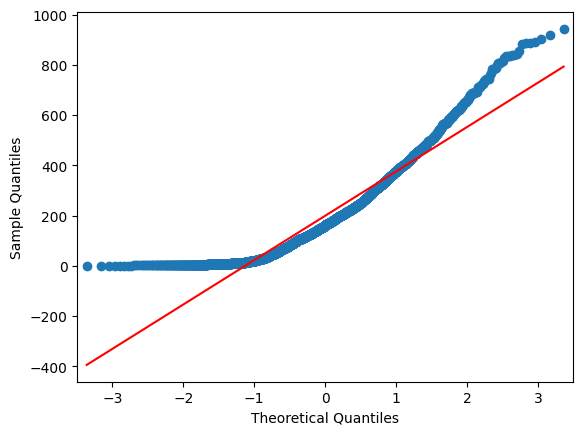

In [57]:
qqplot(winter_season, line= 's')
plt.show()

# **fall_season- QQTEST for normality**

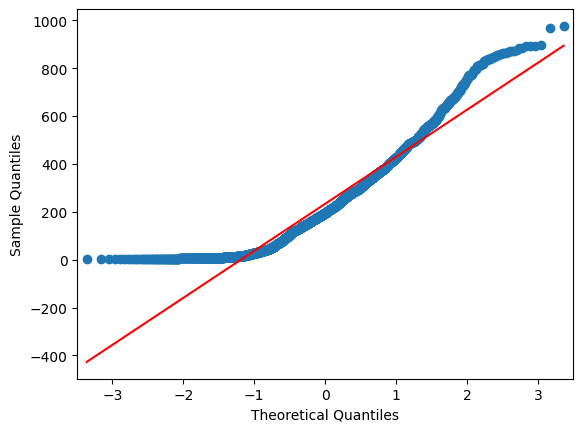

In [58]:
qqplot(fall_season, line= 's')
plt.show()

# **summer_season- QQTEST for normality**

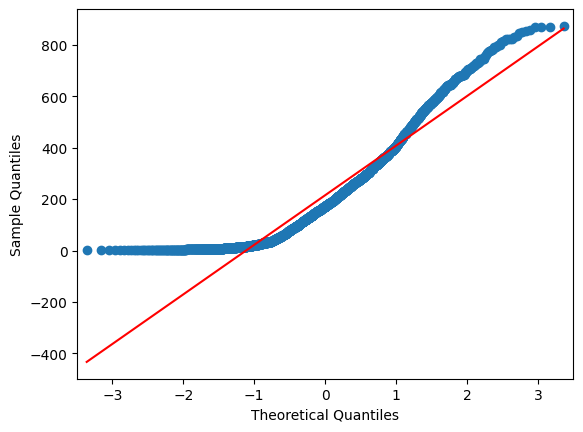

In [59]:
qqplot(summer_season, line= 's')
plt.show()

# **spring_season- QQTEST for normality**

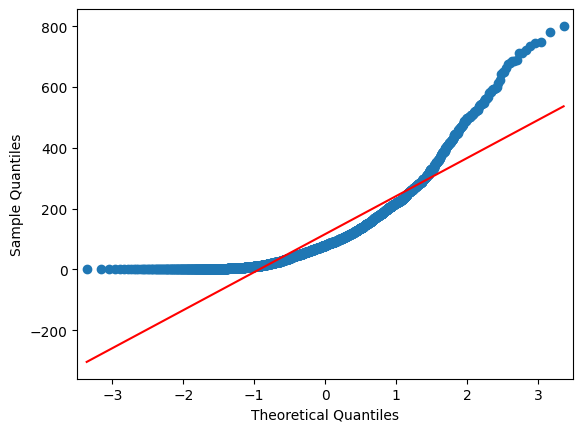

In [60]:
qqplot(spring_season, line= 's')
plt.show()

**From QQTEST we can see that the rides demands on diffrent types of seasons do NOT follow normal distribution.**

# **Histplot/Kdeplot Test for Normality**

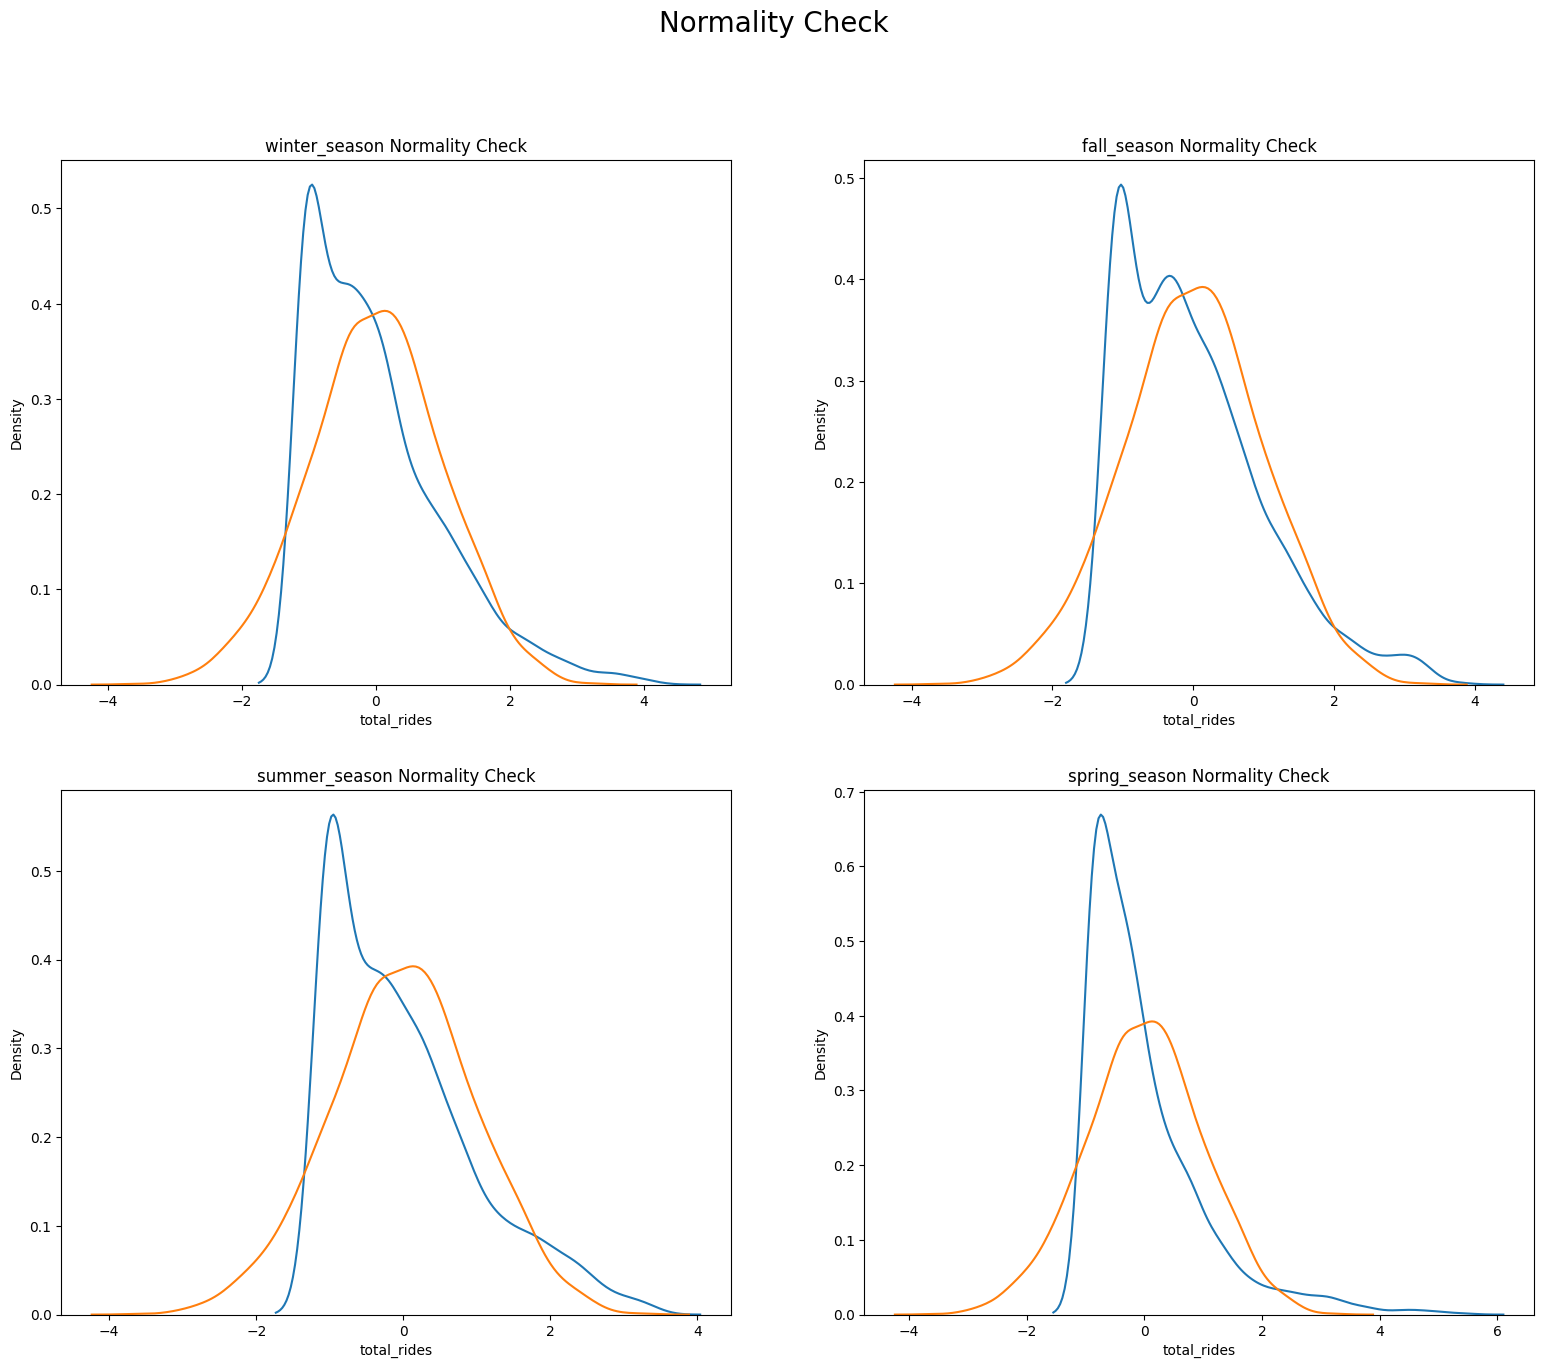

In [61]:
std_norm= np.random.normal(0, 1, 3000)

winter_season_z= zscore(winter_season)
fall_season_z= zscore(fall_season)
summer_season_z= zscore(summer_season)
spring_season_z= zscore(spring_season)

plt.figure(figsize = (19,15))
plt.suptitle('Normality Check', fontsize=20)

plt.subplot(2,2,1)
plt.title('winter_season Normality Check')
sns.kdeplot(winter_season_z)
sns.kdeplot(std_norm)

plt.subplot(2,2,2)
plt.title('fall_season Normality Check')
sns.kdeplot(fall_season_z)
sns.kdeplot(std_norm)

plt.subplot(2,2,3)
plt.title('summer_season Normality Check')
sns.kdeplot(summer_season_z)
sns.kdeplot(std_norm)

plt.subplot(2,2,4)
plt.title('spring_season Normality Check')
sns.kdeplot(spring_season_z)
sns.kdeplot(std_norm)
plt.show()

**From KDE Plot we can see that the rides demands on diffrent types of seasons do NOT follow normal distribution.**

# **Check Skewness & Kurtosis**

In [62]:
seasons_cat= [winter_season, fall_season, summer_season, spring_season]
seasons_cat_name= ['winter_season', 'fall_season', 'summer_season', 'spring_season']
for j,i in enumerate(seasons_cat):
    print(f"Skewness of {seasons_cat_name[j]}: ", i.skew())
    print(f"Kurtosis of {seasons_cat_name[j]}: ", i.kurt())
    print('-'*50)
    print()

Skewness of winter_season:  1.157538240449494
Kurtosis of winter_season:  1.2116862294280852
--------------------------------------------------

Skewness of fall_season:  0.9894160921403976
Kurtosis of fall_season:  0.6791238214390214
--------------------------------------------------

Skewness of summer_season:  1.0114657420522721
Kurtosis of summer_season:  0.4424858601458306
--------------------------------------------------

Skewness of spring_season:  1.9011941976663438
Kurtosis of spring_season:  4.417745665260869
--------------------------------------------------



**We can see that there is skewness and kurtosis in different Seasons rides**

# **Kolmogorov-Smirnov Test For Normality**

>$H_o:$ Data follows Gaussian distribution

>$H_a:$ Data do NOT follow Gaussian distribution

In [63]:
seasons_cat2= [winter_season_z, fall_season_z, summer_season_z, spring_season_z]

for j,i in enumerate(seasons_cat2):
    kstat, p_value= kstest(i, 'norm')
    print(f'{seasons_cat_name[j]}:')
    print(f"Test_stat : {kstat} , P_Value : {p_value}")
    print()
    alpha = 0.05
    test_result(p_value, alpha)
    print('-'*50)
    print()

winter_season:
Test_stat : 0.13090705375603423 , P_Value : 2.6138265755886348e-39

As the p-value 2.6138265755886348e-39 is less than the level of significance, we reject the null hypothesis.
--------------------------------------------------

fall_season:
Test_stat : 0.11837276398196495 , P_Value : 3.357891882456083e-32

As the p-value 3.357891882456083e-32 is less than the level of significance, we reject the null hypothesis.
--------------------------------------------------

summer_season:
Test_stat : 0.13335170134400554 , P_Value : 8.836424772366107e-41

As the p-value 8.836424772366107e-41 is less than the level of significance, we reject the null hypothesis.
--------------------------------------------------

spring_season:
Test_stat : 0.1779987820720204 , P_Value : 1.5514220519715632e-72

As the p-value 1.5514220519715632e-72 is less than the level of significance, we reject the null hypothesis.
--------------------------------------------------



**We can see from KS test that all the different seasons values do not follow normal distribution**

# **Shapiro-Wilk’s test**

We will test the null hypothesis

>$H_0:$ Count follows normal distribution

against the alternative hypothesis

>$H_a:$ Count doesn't follow normal distribution



In [64]:
for j,i in enumerate(seasons_cat):
    shapiro_stat, p_value= shapiro(i)
    print(f'{seasons_cat_name[j]}:')
    print(f"Test_stat : {shapiro_stat} , P_Value : {p_value}")
    print()
    alpha = 0.05
    test_result(p_value, alpha)
    print('-'*50)
    print()

winter_season:
Test_stat : 0.8971884119403579 , P_Value : 1.238194311651477e-38

As the p-value 1.238194311651477e-38 is less than the level of significance, we reject the null hypothesis.
--------------------------------------------------

fall_season:
Test_stat : 0.9145197464602777 , P_Value : 5.311930484402632e-36

As the p-value 5.311930484402632e-36 is less than the level of significance, we reject the null hypothesis.
--------------------------------------------------

summer_season:
Test_stat : 0.8990276865949627 , P_Value : 2.2619064847835511e-38

As the p-value 2.2619064847835511e-38 is less than the level of significance, we reject the null hypothesis.
--------------------------------------------------

spring_season:
Test_stat : 0.8085883911877121 , P_Value : 3.286508136677242e-48

As the p-value 3.286508136677242e-48 is less than the level of significance, we reject the null hypothesis.
--------------------------------------------------



**We can see from Shapiro-Wilk’s test that all the different seasons values do not follow normal distribution**

# **Variances Checks**

In [65]:
data.groupby('season', observed=False)['total_rides'].describe()

,count,mean,std,min,25%,50%,75%,max
season,,,,,,,,
fall,2733.0,234.417124,197.151001,1.0,68.0,195.0,347.0,977.0
spring,2686.0,116.343261,125.273974,1.0,24.0,78.0,164.0,801.0
summer,2733.0,215.251372,192.007843,1.0,49.0,172.0,321.0,873.0
winter,2734.0,198.988296,177.622409,1.0,51.0,161.0,294.0,948.0


In [66]:
print('Variances Check:')
print(f'winter_season: {winter_season.var()}, fall_season: {fall_season.var()}, summer_season: {summer_season.var()}, spring_season: {spring_season.var()}')

Variances Check:
winter_season: 31178.887725900462, fall_season: 38608.868565424535, summer_season: 37113.40036108561, spring_season: 15620.695189865943


**We can see there is difference in Variances for different seasons groups**

#**Levene’s test**

>$H_0$: All the count variances are equal

>$H_a$: At least one variance is different from the rest

In [67]:
levene_stat, p_value = levene(winter_season, fall_season, spring_season, summer_season)
print(f"Levene_stat : {levene_stat} , P_Value : {p_value}")
print()
alpha = 0.05
test_result(p_value, alpha)

Levene_stat : 182.53733178857576 , P_Value : 2.368521262252955e-115

As the p-value 2.368521262252955e-115 is less than the level of significance, we reject the null hypothesis.


**We can see from levene test that there is difference in Variances for different seasons groups**

**The assumptions of ANOVA Test are not satisfied so we can go with KRUSKAL_WALIS H TEST. We will perform both.**

# **One-Way ANOVA Test**

In [68]:
anova_stat, p_value = f_oneway(winter_season, fall_season, spring_season, summer_season)
print(f"Anova_stat : {anova_stat} , P_Value : {p_value}")
print()
alpha = 0.05
test_result(p_value, alpha)

Anova_stat : 226.73144669854864 , P_Value : 1.7134458205229114e-142

As the p-value 1.7134458205229114e-142 is less than the level of significance, we reject the null hypothesis.


**The mean number of bikes rented is different across at Seasons conditions**

# **KRUSKAL_WALIS H TEST**

In [69]:
kruskal_stat, p_value = kruskal(winter_season, fall_season, spring_season, summer_season)
print(f"kruskal_stat : {kruskal_stat} , P_Value : {p_value}")
print()
alpha = 0.05
test_result(p_value, alpha)

kruskal_stat : 666.754007568729 , P_Value : 3.3945299060495527e-144

As the p-value 3.3945299060495527e-144 is less than the level of significance, we reject the null hypothesis.


**From both ANOVA and KRUSKAL_WALIS H TEST we can say that the mean number of bikes rented is different across at seasons conditions.**

**Let us find out Which season has more bookings.**

**Using 2 independent sample Ttest.**

In [70]:
#Ho: u1>=u2
#Ha: u1<u2

test_stat, p_value = ttest_ind(winter_season, fall_season, alternative= 'less')
print(f"Test_stat : {test_stat} , P_Value : {p_value}")
print()
alpha = 0.05
test_result(p_value, alpha)

Test_stat : -6.6275584564269066 , P_Value : 1.8791883396131227e-11

As the p-value 1.8791883396131227e-11 is less than the level of significance, we reject the null hypothesis.


**Average booking on winter_season is less than Average fall_season booking**

In [71]:
#Ho: u1>=u2
#Ha: u1<u2

test_stat, p_value = ttest_ind(winter_season, summer_season, alternative= 'less')
print(f"Test_stat : {test_stat} , P_Value : {p_value}")
print()
alpha = 0.05
test_result(p_value, alpha)

Test_stat : -3.0889680158057486 , P_Value : 0.0010095669777506532

As the p-value 0.0010095669777506532 is less than the level of significance, we reject the null hypothesis.


**Average booking on winter_season is less than Average summer_season booking**

In [72]:
#Ho: u1<=u2
#Ha: u1>u2

test_stat, p_value = ttest_ind(winter_season, spring_season, alternative= 'greater')
print(f"Test_stat : {test_stat} , P_Value : {p_value}")
print()
alpha = 0.05
test_result(p_value, alpha)

Test_stat : 19.506896648522417 , P_Value : 3.808205302502407e-82

As the p-value 3.808205302502407e-82 is less than the level of significance, we reject the null hypothesis.


**Average booking on winter_season is greater than Average spring_season booking**

In [73]:
#Ho: u1<=u2
#Ha: u1>u2

test_stat, p_value = ttest_ind(fall_season, summer_season, alternative= 'greater')
print(f"Test_stat : {test_stat} , P_Value : {p_value}")
print()
alpha = 0.05
test_result(p_value, alpha)

Test_stat : 3.4290433900386117 , P_Value : 0.0003052099772783438

As the p-value 0.0003052099772783438 is less than the level of significance, we reject the null hypothesis.


**Average booking on fall_season is greater than Average summer_season booking**

In [74]:
#Ho: u1<=u2
#Ha: u1>u2

test_stat, p_value = ttest_ind(fall_season, spring_season, alternative= 'greater')
print(f"Test_stat : {test_stat} , P_Value : {p_value}")
print()
alpha = 0.05
test_result(p_value, alpha)

Test_stat : 25.639768637249958 , P_Value : 6.25996128952799e-137

As the p-value 6.25996128952799e-137 is less than the level of significance, we reject the null hypothesis.


**Average booking on fall_season is greater than Average spring_season booking**

In [75]:
#Ho: u1<=u2
#Ha: u1>u2

test_stat, p_value = ttest_ind(summer_season, spring_season, alternative= 'greater')
print(f"Test_stat : {test_stat} , P_Value : {p_value}")
print()
alpha = 0.05
test_result(p_value, alpha)

Test_stat : 21.891754372318882 , P_Value : 5.4055874949529074e-102

As the p-value 5.4055874949529074e-102 is less than the level of significance, we reject the null hypothesis.


**Average booking on summer_season is greater than Average spring_season booking**

**We can say that Average booking on fall_season is the highest followed by summer_season, winter_season and then spring_season.**

# **6. Check if the Weather conditions are significantly different during different Seasons?**

**a. Formulate Null Hypothesis (H0) and Alternate Hypothesis (H1)**

**i. Hint: The values in ‘Weather’ &‘Season’ columns should be treated as
distinct Categories. Encode them accordingly.**

**b. Select an appropriate test -**

**i. Hint: Chi-square test**

**c. Create a Contingency Table against ‘Weather’ & ‘Season’ columns**

**i. Hint: You can use a Pandas’ CrossTab**

**d. Set a significance level and Calculate the test Statistics / p-value.**

**i. Hint: alpha=5% is recommended**

**e. Decide whether to accept or reject the Null Hypothesis.**

**Hint:**

**i. If the p-value is less than or equal to the predetermined level of
significance (alpha), we have evidence to reject the null hypothesis.**

**ii. If the p-value is greater than the predetermined level of significance
(alpha), we do not have sufficient evidence to reject the null hypothesis.
f. Draw inferences & conclusions from the analysis and provide recommendations.**

# **Step 1: Define The Null And Alternate Hypothesis**


$H_0:$ The demand of bikes on Weather conditions are independent of the season.

$H_a:$ The demand of bikes on Weather conditions are dependent of the season.

# **Step 2: Select An Appropriate Test**

We will go ahead with Chi-square test as we are comparing two different categorical variables, 'season' and 'weather'.

# **Step 3: Checking For Basic Assumpitons For The Hypothesis.**

1. The data in the cells should be frequencies, or counts of cases.

2. The levels (or categories) of the variables are mutually exclusive. That is, a particular subject fits into one and only one level of each of the
variables.

3. There are 2 variables, and both are measured as categories.

4. The value of the cell expecteds should be 5 or morein at least 80% of the cells, and no cell should have an expected of less than one (3).

# **Step 4: Decide a test statistic and a corresponding distribution.**

**Test Statistic**: Chi-Square-Stats

**Distribution**: Chi-Square-Distribution

# **Step 5: Determine which test should be used.**

Here we will perform the chisquare Test of independence (i.e) chi2_contingency

# **Step 6: Determine the p-value and Choose a significance level.**

we will be computing the chisquare-stat value using the chi2_contingency functions.

We set our alpha to be 0.05 (i.e) confidence level = 95%

# **Step 7: Compare p-value and alpha.**
Based on p-value, we will accept or reject Ho.

p-val > alpha : Failed To Reject Ho

p-val < alpha : Reject Ho


In [76]:
contigency= pd.crosstab(data['season'], data.loc[data['weather']!='Heavy_Rain', 'weather'])
contigency

weather,Clear,Light_Snow,Mist
season,,,
fall,1930,199,604
spring,1759,211,715
summer,1801,224,708
winter,1702,225,807


<Axes: xlabel='season'>

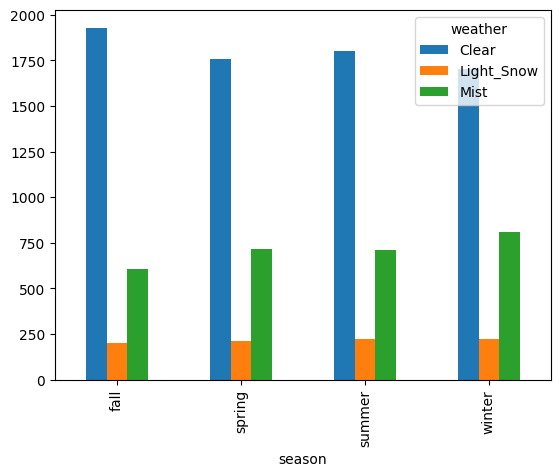

In [77]:
contigency.plot(kind= 'bar')

# **Chi-squared test**

In [78]:
chi2_stat, p_value, dof, exp_freq = chi2_contingency(contigency, correction=False)
print('Chi-square Statistic: {} \n P-value: {} \n Degree of Freedom: {} \n Expected Frequencies: {}'.format(chi2_stat, p_value, dof, exp_freq))
print()
alpha = 0.05
test_result(p_value, alpha)

Chi-square Statistic: 46.10145731073249 
 P-value: 2.8260014509929343e-08 
 Degree of Freedom: 6 
 Expected Frequencies: [[1805.76352779  215.67726229  711.55920992]
 [1774.04869086  211.8892972   699.06201194]
 [1805.76352779  215.67726229  711.55920992]
 [1806.42425356  215.75617823  711.81956821]]

As the p-value 2.8260014509929343e-08 is less than the level of significance, we reject the null hypothesis.


**We have enough statistical evidence to say that the weather Conditions are dependent on the Various Season.**

# **7. Check if there any significant difference between the no. of bike rides on Holidays and Non-Holidays?**

**a. Formulate Null Hypothesis (H0) and Alternate Hypothesis (H1)**

**b. Select an appropriate test -**

**i. Hint: 2- Sample Independent T-test**

**c. Set a significance level**

**i. Hint: alpha=5% is recommended**

**d. Calculate test Statistics / p-value**

**e. Decide whether to accept or reject the Null Hypothesis.**

**Hint:**

**i. If the p-value is less than or equal to the predetermined level of significance (alpha), we have evidence to reject the null hypothesis.**

**ii. If the p-value is greater than the predetermined level of significance
(alpha), we do not have sufficient evidence to reject the null hypothesis.**

**f. Draw inferences & conclusions from the analysis and provide recommendations.**

# **Step 1: Define The Null And Alternate Hypothesis**


$H_0:$ The demand of bikes on holidays is SIMILAR to the demand of bikes on non-holidays.

$H_a:$ The demand of bikes on holidays is NOT SIMILAR to the demand of bikes on non-holidays.

Let $\mu_1$ and $\mu_2$ be the average no. of bikes rented on weekdays and weekends respectively.

Mathematically, the above formulated hypothesis can be written as:

$H_0: \mu_1  =  \mu_2$

$H_a: \mu_1  !=  \mu_2$

# **Step 2: Select An Appropriate Test**

We Can use Z-test or T-test as sample size if high. Population mean and std is not known. We will use 2 Sample T-test here.

**Assumptions of T-Test**
1. The sample size should be less than 30.
2. The population variance is unknown.
3. The population mean and standard deviation are finite.
4. The means of the two populations being compared should follow normal distributions.
5. If using Student's original definition of the t-test, the two populations being compared should have the same variance. If the sample sizes in the two groups being compared are equal, Student's original t-test is highly robust to the presence of unequal variances.


# **Step 3: Checking For Basic Assumpitons For The Hypothesis.**

**Normality checks:**

Distribution check using QQ Plot

Distribution check using Hist/Kde Plot

Confirmation by Shapiro-wilks Test

**Variances checks:**

Homogeneity of Variances using Levene's test

# **Step 4: Decide a test statistic and a corresponding distribution.**

**Test Statistic**: T-Stats

**Distribution**: T-Distribution

If data follows normal distribution we go with ttest_ind

Else we will go with Mannwhitney_u test (Non - Parametric test)

# **Step 5: Determine whether the test should be left-tailed, right-tailed, or two-tailed.**

We will perform two-tailed and later go with left or right tailed test after the results of two-tailed test, if needed.

# **Step 6: Determine the p-value and Choose a significance level.**

we will be computing the t-stat value using the ttest function using scip.stats.

We set our alpha to be 0.05 (i.e) confidence level = 95%

# **Step 7: Compare p-value and alpha.**
Based on p-value, we will accept or reject Ho.

p-val > alpha : Failed To Reject Ho

p-val < alpha : Reject Ho


In [79]:
data['holiday'].value_counts()

,count
holiday,
no,10575
yes,311


In [80]:
holiday_rides= data.loc[data['holiday']=='yes', 'total_rides'].sample(300)
non_holiday_rides= data.loc[data['holiday']=='no', 'total_rides'].sample(300)

**Why do we take same no. of samples from two different populations for conducting the tests?**

**Ans.**
* Unequal sample sizes can lead to unequal variances between samples, which affects the assumption of equal variances in tests like t-test, ANOVA, etc.

* Having both unequal sample sizes and variances dramatically affects the statistical power of a test.

# **Normality Checks**

# **holiday_rides- QQTEST for normality**

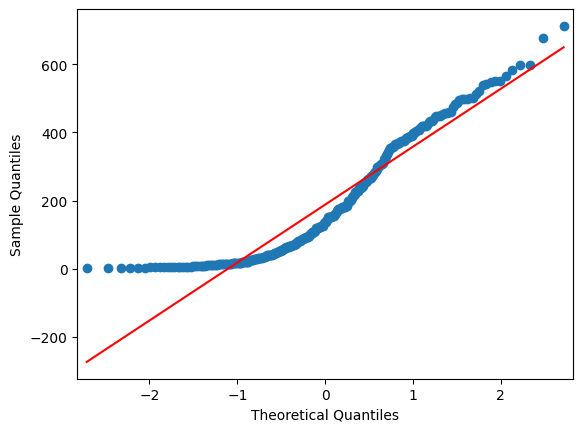

In [81]:
qqplot(holiday_rides, line= 's')
plt.show()

# **non_holiday_rides- QQTEST for normality**

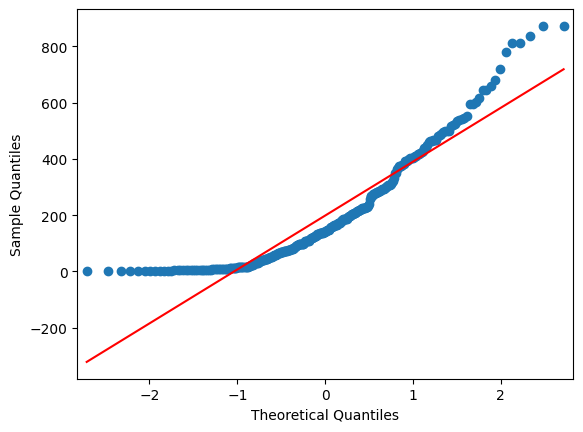

In [82]:
qqplot(non_holiday_rides, line= 's')
plt.show()

**From QQTEST we can see that the rides demands on non_holiday_rides or holiday_rides do NOT follow normal distribution.**

# **Histplot/Kdeplot Test for Normality**

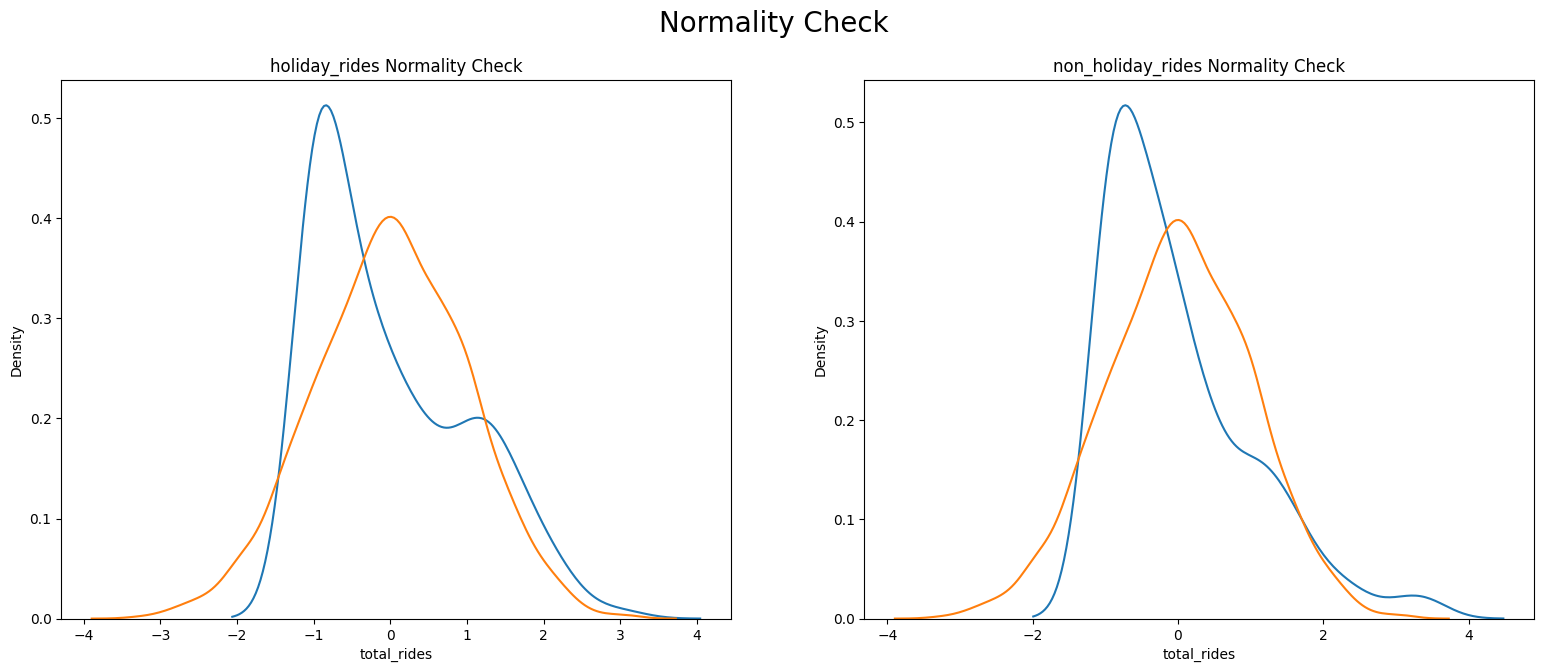

In [83]:
std_norm= np.random.normal(0, 1, 3000)

holiday_rides_z= zscore(holiday_rides)
non_holiday_rides_z= zscore(non_holiday_rides)

plt.figure(figsize = (19,7))
plt.suptitle('Normality Check', fontsize=20)

plt.subplot(1,2,1)
plt.title('holiday_rides Normality Check')
sns.kdeplot(holiday_rides_z)
sns.kdeplot(std_norm)

plt.subplot(1,2,2)
plt.title('non_holiday_rides Normality Check')
sns.kdeplot(non_holiday_rides_z)
sns.kdeplot(std_norm)
plt.show()

**From KDE PLOT we can see that the rides demands on non_holiday_rides or holiday_rides do NOT follow normal distribution.**

# **Shapiro Test For Normality**

>$H_o:$ Data follows Gaussian distribution

>$H_a:$ Data do NOT follow Gaussian distribution

In [84]:
#holiday_rides
shapiro_stat , p_val = shapiro(holiday_rides)
print(f"Shapiro_stat : {shapiro_stat} , P_Value : {p_val}")
print()
if p_val > 0.05:
	print('Data Follows Gaussian distribution')
else:
	print('Data Do NOT Follow Gaussian distribution')

Shapiro_stat : 0.893560557740813 , P_Value : 1.178101710419978e-13

Data Do NOT Follow Gaussian distribution


In [85]:
#non_holiday_rides
shapiro_stat , p_val = shapiro(non_holiday_rides)
print(f"Shapiro_stat : {shapiro_stat} , P_Value : {p_val}")
print()
if p_val > 0.05:
	print('Data Follows Gaussian distribution')
else:
	print('Data Do NOT Follow Gaussian distribution')

Shapiro_stat : 0.8719201037524544 , P_Value : 4.203343327733988e-15

Data Do NOT Follow Gaussian distribution


**We conclude that the samples do not follow normal distribution**

# **Variances Checks**

In [86]:
data.groupby('holiday', observed=True)['total_rides'].describe()

,count,mean,std,min,25%,50%,75%,max
holiday,,,,,,,,
no,10575.0,191.741655,181.513131,1.0,43.0,145.0,283.0,977.0
yes,311.0,185.877814,168.300531,1.0,38.5,133.0,308.0,712.0


#**Levene’s test**

>$H_0$: All the count variances are equal

>$H_a$: At least one variance is different from the rest

In [87]:
levene_stat, p_val = levene(holiday_rides, non_holiday_rides)
print(f"Levene_stat : {levene_stat} , P_Value : {p_val}")
print()
if p_val > 0.05:
	print('Data Has Similar Variance')
else:
	print('Data Do NOT Have Similar Variance')

Levene_stat : 0.2510662733543015 , P_Value : 0.6165096640247218

Data Has Similar Variance


**Here we can see that both groups have same variance.**

**We conclude that the 2 sample have same variance but are not normally distributed. T-Test cannot be applied here, we can perform its non parametric
equivalent test i.e., Mann-Whitney U rank test for two independent samples. But we will try to compare both tests.**

# **2-Sample Independent T-Test**

**Two-Tailed Test**

In [88]:
test_stat, p_value = ttest_ind(holiday_rides, non_holiday_rides)
print(f"Test_stat : {test_stat} , P_Value : {p_value}")
print()
alpha = 0.05
test_result(p_value, alpha)

Test_stat : -0.7157777154097384 , P_Value : 0.47440800603291

As the p-value 0.47440800603291 is greater than the level of significance, we fail to reject the null hypothesis.


**Test Result: We Fail to reject Null Hypothesis that means there is no significant difference between non_holiday_rides and holiday_rides ride counts**

# **MannWhitney u Rank test(Non-Parametric Test)**

In [89]:
test_stat, p_value = mannwhitneyu(holiday_rides, non_holiday_rides)
print(f"Test_stat : {test_stat} , P_Value : {p_value}")
print()
alpha = 0.05
test_result(p_value, alpha)

Test_stat : 44563.0 , P_Value : 0.8371024823238375

As the p-value 0.8371024823238375 is greater than the level of significance, we fail to reject the null hypothesis.


**Test Result: We Fail to reject Null Hypothesis that means there is no significant difference between non_holiday_rides and holiday_rides ride counts**

**From both 2-Sample T-Test and MannWhitney U Rank Test we conclude that there is no significant difference between non_holiday_rides and holiday_rides ride counts.**

# **Insights**

***Seasonal Patterns***

***Spring sees the highest average bookings compared to other seasons.***

***Rentals peak during summer, while the lowest counts are observed in winter.***

***Seasonal weather significantly influences bike rental demand, with clear weather and partly cloudy conditions correlating with the highest rentals.***

**Weather Impact**

***Light snow and light rain combined with thunderstorm or scattered clouds result in higher average bookings than other weather conditions.***

**Humidity:**

***Medium (25-50) and high (50-75) humidity levels see the most bookings.***

***Low humidity (<25) correlates with the least bookings.***

**Temperature:**

***Medium (18-28°C) temperature conditions see the highest rentals, followed by high (28-41°C) and low (0-18°C) ranges.***

**Wind Speed:**

***Low wind speeds (1-20) see higher bookings compared to moderate or high speeds.***

**Day-of-Week and Holidays**

***No significant difference in bookings between working vs. non-working days or holidays vs. non-holidays.***

***However, weekday rentals are generally higher than weekends.***

**User Behavior**

**Casual riders dominate rentals during weekends, while registered users drive weekday rentals.***

***Around 81% of users are registered, while 19% are casual riders.***

**Statistical Observations**

***The distribution of rental counts is right-skewed.***

***Columns like temp and atemp show high multicollinearity.***

***Outliers were observed in the count column.***

# **Recommendations**

**Seasonal Promotions:**

***Target spring and summer with discounts, loyalty programs, or promotional packages to maximize bookings.***

***Create awareness campaigns during fall and winter to boost off-peak rentals.***

**Dynamic Pricing:**

***Implement time-based pricing to increase usage during off-peak hours and optimize revenue.***

**Weather-Sensitive Promotions:**

***Launch marketing campaigns on days with favorable weather (clear or partly cloudy conditions).***

***Introduce rain-specific offers like discounts for rides in light rain conditions.***

**Inventory Management:**

***Maintain a flexible inventory system to meet demand during high-traffic seasons and weather conditions.***

**Comfort-Oriented Amenities:**

***Provide raincoats or umbrellas during light rain.***

***Offer temperature-sensitive adjustments to enhance comfort during rides.***

**User Segmentation Marketing:**

***Promote loyalty programs for registered users and introduce benefits for casual users to encourage registrations.***

**Seasonal Bike Maintenance:**

***Ensure thorough bike checks during seasonal transitions to avoid breakdowns.
Plan maintenance during low-demand months.***

**Data-Driven Collaboration:**

***Partner with weather services for real-time updates and integrate them into marketing efforts.***

**Social Media Engagement:**

***Use platforms to share user testimonials, run targeted advertisements, and promote favorable biking conditions.***

#**Hypothesis Testing Results**

**Key Findings:**

**Seasonal Impact:**

***The demand for bike rentals varies significantly across different seasons (ANOVA confirms statistical significance).***

***Weather conditions are strongly influenced by seasons (Chi-square test confirms dependency).***

**Day of the Week and Holiday Impact:**

***No significant difference in rentals between weekends and weekdays (2-sample t-test confirms limited impact).***

***No significant difference in rentals between holidays and regular days (2-sample t-test confirms limited impact).***

**Weather Conditions:**

***The demand for rentals differs across various weather conditions (ANOVA confirms significance).***

**Rental Distribution:**

***The rental count distribution is not normal but skewed towards the right, indicating higher occurrences of lower booking counts.***

# **Business Implications**

**Optimize for High-Demand Conditions:**

***Capitalize on medium humidity and temperature ranges (18-28°C).***
***Plan for peak demand during spring and summer.***

**Increase Accessibility:**

***Ensure bike availability during favorable weather and low wind speeds.***

**Focus on Registered Users:**

***Enhance retention strategies, as 81% of users are registered.***

***Use casual user trends for conversion campaigns.***

**Leverage Skewed Demand:**

***Plan for the skew in rentals by ensuring enough stock for high-demand days and offering dynamic discounts to stimulate low-demand periods.***

# **THANK YOU**

# **-Yulu Case Study By: Nitish Vishwanath Hatapaki**